# 🛒 Smart Retail Analytics & Customer Segmentation Platform

### End-to-End Machine Learning Project

**Author:** Sandeep Vyas

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, MLxtend

**Machine Learning Techniques:**
- RFM Analysis
- K-Means Clustering
- DBSCAN Clustering
- Hierarchical Clustering
- Principal Component Analysis (PCA)
- Apriori Algorithm
- Association Rule Mining
- FP-Growth Algorithm

**Project Type:** Customer Segmentation & Market Basket Analysis

**Dataset:** UCI Online Retail II Dataset (2009–2011)

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.frequent_patterns import fpgrowth

from scipy.cluster.hierarchy import dendrogram, linkage
from datetime import datetime

# Smart Retail Analytics & Customer Segmentation Platform
### Project Objective
The objective of this project is to analyze retail transaction data, identify customer purchasing behavior, perform customer segmentation using clustering algorithms, and generate business insights to improve sales and customer retention.

In [2]:
df_2009 = pd.read_csv("Online_retail_2009-2010.csv")
df_2010 = pd.read_csv("Online_retail_2010-2011.csv")

In [3]:
df = pd.concat([df_2009, df_2010], ignore_index=True)
print("Dataset merged successfully.")

Dataset merged successfully.


In [4]:
df.shape

(1067371, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [6]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [8]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [9]:
duplicate_count = df.duplicated().sum()
print("Duplicate Records :", duplicate_count)

Duplicate Records : 34335


In [10]:
df = df.drop_duplicates()
print("Shape after removing duplicates :", df.shape)

Shape after removing duplicates : (1033036, 8)


In [11]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4275
Quantity            0
InvoiceDate         0
Price               0
Customer ID    235151
Country             0
dtype: int64

In [12]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

Customer ID    22.763098
Description     0.413829
Invoice         0.000000
StockCode       0.000000
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Country         0.000000
dtype: float64

In [13]:
cancelled_orders = df[df["Invoice"].astype(str).str.startswith("C")]
print("Cancelled Orders :", cancelled_orders.shape[0])

Cancelled Orders : 19104


In [14]:
cancelled_orders.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [15]:
(cancelled_orders["Quantity"] < 0).value_counts()

Quantity
True     19103
False        1
Name: count, dtype: int64

In [16]:
(cancelled_orders["Price"] < 0).value_counts()

Price
False    19104
Name: count, dtype: int64

In [17]:
cancelled_orders[cancelled_orders["Quantity"] >= 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
76799,C496350,M,Manual,1,2010-02-01 08:24:00,373.57,NaN,United Kingdom


In [18]:
df = df[~df["Invoice"].astype(str).str.startswith("C")]
print("Shape after removing cancelled orders :", df.shape)

Shape after removing cancelled orders : (1013932, 8)


In [19]:
df[df["Invoice"].astype(str).str.startswith("C")].shape

(0, 8)

In [20]:
(df["Quantity"] < 0).sum()

np.int64(3393)

In [21]:
(df["Price"] < 0).sum()

np.int64(5)

In [22]:
negative_quantity = df[df["Quantity"] < 0]
print("Negative Quantity Records :", negative_quantity.shape)
negative_quantity.head(10)

Negative Quantity Records : (3393, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom
4538,489820,21133,invcd as 84879?,-720,2009-12-02 13:23:00,0.0,NaN,United Kingdom
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.0,NaN,United Kingdom


In [23]:
negative_price = df[df["Price"] < 0]
print("Negative Price Records :", negative_price.shape)
negative_price

Negative Price Records : (5, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [24]:
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]
print("Shape after removing invalid transactions :", df.shape)

Shape after removing invalid transactions : (1007913, 8)


In [25]:
print("Negative Quantity :", (df["Quantity"] < 0).sum())
print("Zero Quantity :", (df["Quantity"] == 0).sum())
print("Negative Price :", (df["Price"] < 0).sum())
print("Zero Price :", (df["Price"] == 0).sum())

Negative Quantity : 0
Zero Quantity : 0
Negative Price : 0
Zero Price : 0


# Feature Engineering

In this section, we create meaningful features from the existing data to improve business analysis and machine learning performance.

In [26]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print(df["InvoiceDate"].dtype)

datetime64[ns]


In [27]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour
df["Weekday"] = df["InvoiceDate"].dt.day_name()

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year,Month,Day,Hour,Weekday
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,1,7,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,1,7,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,1,7,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009,12,1,7,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009,12,1,7,Tuesday


In [28]:
df["TotalAmount"] = df["Quantity"] * df["Price"]
df[["Quantity", "Price", "TotalAmount"]].head()

,Quantity,Price,TotalAmount
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [29]:
df["MonthName"] = df["InvoiceDate"].dt.month_name()
df[["InvoiceDate","Month","MonthName"]].head()

,InvoiceDate,Month,MonthName
0,2009-12-01 07:45:00,12,December
1,2009-12-01 07:45:00,12,December
2,2009-12-01 07:45:00,12,December
3,2009-12-01 07:45:00,12,December
4,2009-12-01 07:45:00,12,December


In [30]:
df["Quarter"] = df["InvoiceDate"].dt.quarter
df[["InvoiceDate","Quarter"]].head()

,InvoiceDate,Quarter
0,2009-12-01 07:45:00,4
1,2009-12-01 07:45:00,4
2,2009-12-01 07:45:00,4
3,2009-12-01 07:45:00,4
4,2009-12-01 07:45:00,4


In [31]:
df["Weekend"] = df["Weekday"].isin(["Saturday","Sunday"])
df[["Weekday","Weekend"]].head()

,Weekday,Weekend
0,Tuesday,False
1,Tuesday,False
2,Tuesday,False
3,Tuesday,False
4,Tuesday,False


In [32]:
def time_slot(hour):

    if 5 <= hour < 12:
        return "Morning"

    elif 12 <= hour < 17:
        return "Afternoon"

    elif 17 <= hour < 21:
        return "Evening"

    else:
        return "Night"

df["TimeSlot"] = df["Hour"].apply(time_slot)
df[["Hour","TimeSlot"]].head()

,Hour,TimeSlot
0,7,Morning
1,7,Morning
2,7,Morning
3,7,Morning
4,7,Morning


In [33]:
order_value = (df.groupby("Invoice")["TotalAmount"]
      .sum()
      .reset_index()
      .rename(columns={"TotalAmount":"OrderValue"}))
order_value.head()

,Invoice,OrderValue
0,489434,505.30
1,489435,145.80
2,489436,630.33
3,489437,310.75
4,489438,2286.24


In [34]:
basket_size = (df.groupby("Invoice")
      .size()
      .reset_index(name="BasketSize"))

basket_size.head()

,Invoice,BasketSize
0,489434,8
1,489435,4
2,489436,19
3,489437,23
4,489438,17


In [35]:
df = df.merge(order_value, on="Invoice", how="left")
df = df.merge(basket_size, on="Invoice", how="left")

In [36]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year,Month,Day,Hour,Weekday,TotalAmount,MonthName,Quarter,Weekend,TimeSlot,OrderValue,BasketSize
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,1,7,Tuesday,83.4,December,4,False,Morning,505.3,8
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,1,7,Tuesday,81.0,December,4,False,Morning,505.3,8
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,1,7,Tuesday,81.0,December,4,False,Morning,505.3,8
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009,12,1,7,Tuesday,100.8,December,4,False,Morning,505.3,8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009,12,1,7,Tuesday,30.0,December,4,False,Morning,505.3,8


# Business KPI Analysis

In this section, we calculate key business performance indicators (KPIs) to understand the overall performance of the retail business before performing detailed exploratory data analysis.

In [37]:
kpi = {"Total Revenue": df["TotalAmount"].sum(),
       "Total Orders": df["Invoice"].nunique(),
       "Total Customers": df["Customer ID"].nunique(),
       "Total Products": df["StockCode"].nunique(),
       "Total Countries": df["Country"].nunique(),
       "Average Basket Size": basket_size["BasketSize"].mean(),
       "Average Revenue Per Customer": df.groupby("Customer ID")["TotalAmount"].sum().mean(),
       "Average Revenue Per Order": df["TotalAmount"].sum() / df["Invoice"].nunique()}

print("=" * 70)
print("BUSINESS KPI SUMMARY")
print("=" * 70)

for key, value in kpi.items():
    if isinstance(value, float):
        print(f"{key:<32} : {value:>15,.2f}")
    else:
        print(f"{key:<32} : {value:>15,}")

print("=" * 70)

BUSINESS KPI SUMMARY
Total Revenue                    :   20,476,260.45
Total Orders                     :          40,077
Total Customers                  :           5,878
Total Products                   :           4,917
Total Countries                  :              43
Average Basket Size              :           25.15
Average Revenue Per Customer     :        2,955.90
Average Revenue Per Order        :          510.92


# 📊 Business-Oriented Exploratory Data Analysis (EDA)

## Sales Analysis

### Objective
The objective of this analysis is to understand the overall sales performance of the retail business by identifying high-revenue countries, top-selling products, monthly sales trends, and quarterly revenue patterns. These insights help the business optimize marketing strategies, inventory planning, and decision-making.

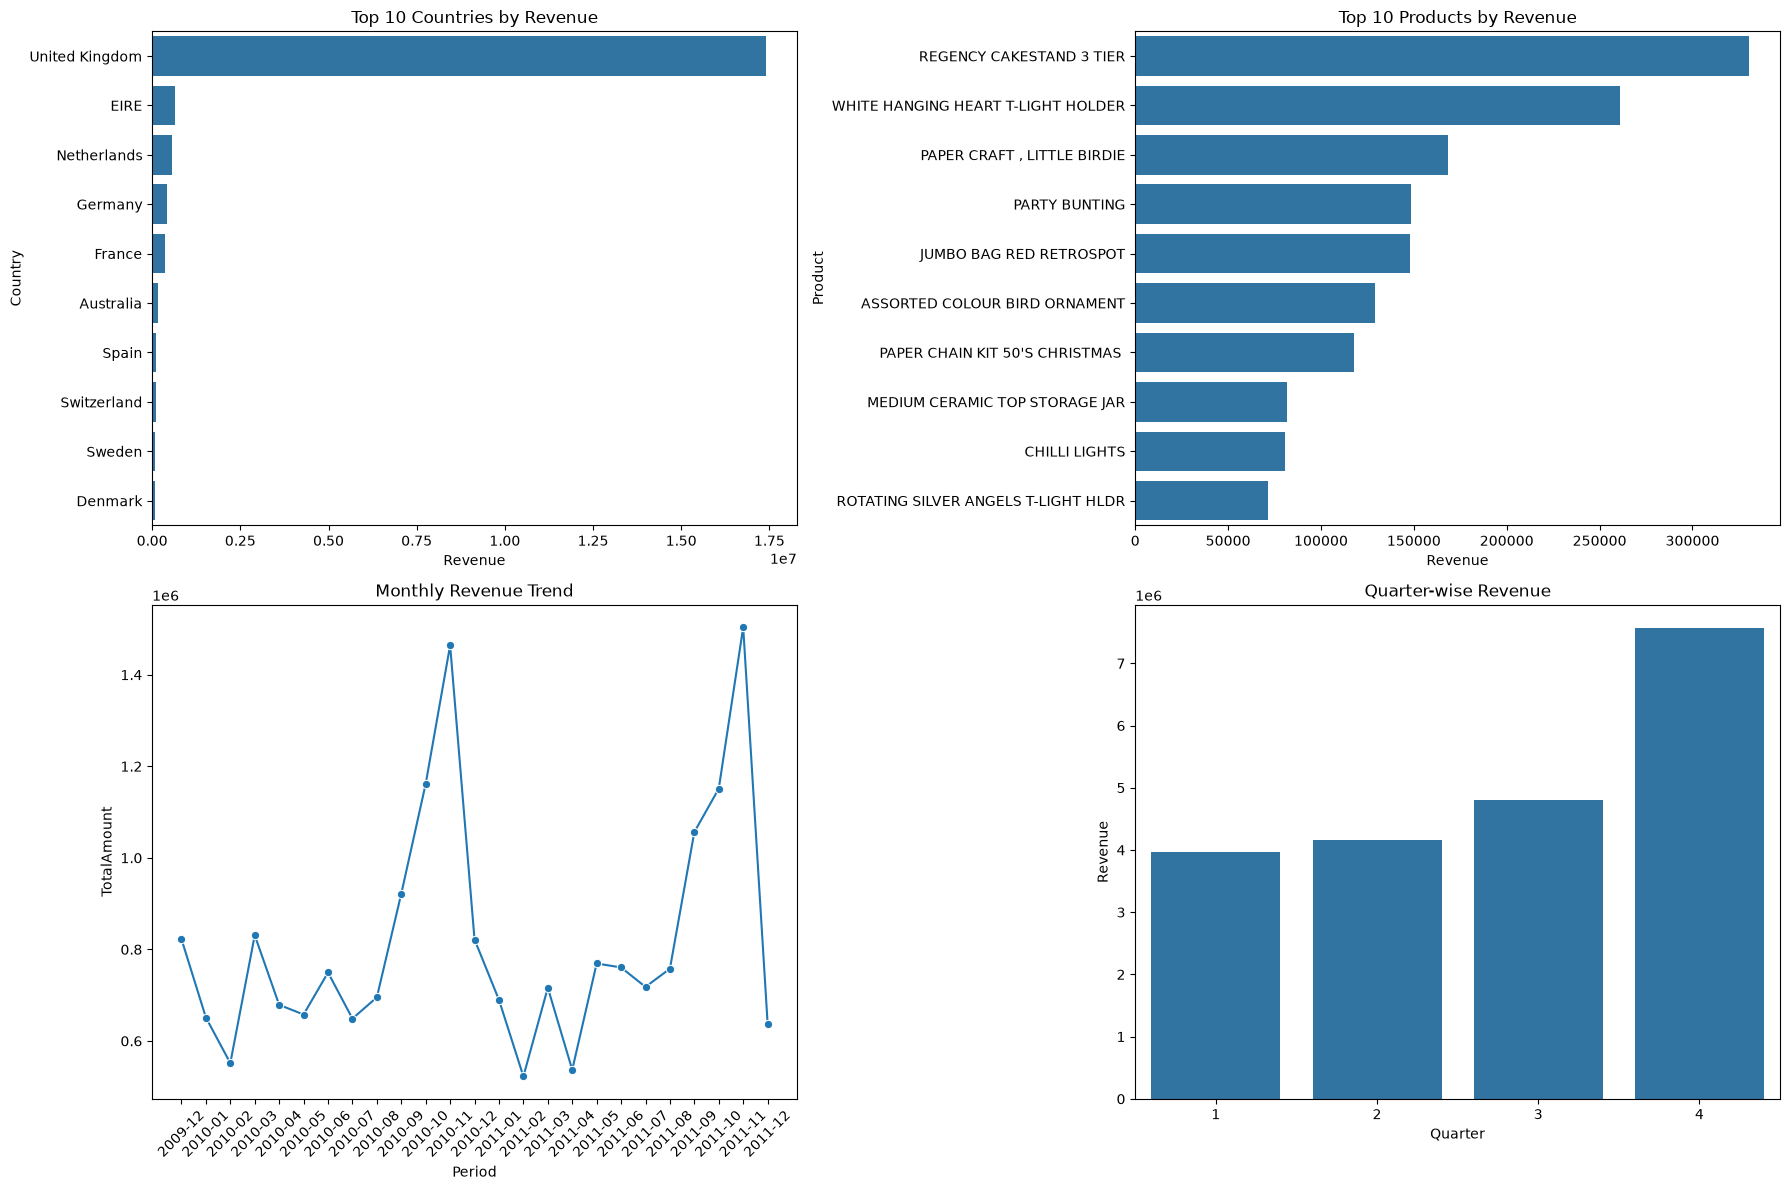

Top 10 Countries by Revenue
Country
United Kingdom    17,410,196.12
EIRE                 658,767.31
Netherlands          554,038.09
Germany              425,019.71
France               350,456.09
Australia            169,283.46
Spain                108,332.49
Switzerland          100,685.59
Sweden                91,869.82
Denmark               68,580.69
Name: TotalAmount, dtype: object

Top 10 Products by Revenue
Description
REGENCY CAKESTAND 3 TIER               330,590.32
WHITE HANGING HEART T-LIGHT HOLDER     260,990.22
PAPER CRAFT , LITTLE BIRDIE            168,469.60
PARTY BUNTING                          148,318.28
JUMBO BAG RED RETROSPOT                148,073.47
ASSORTED COLOUR BIRD ORNAMENT          129,324.49
PAPER CHAIN KIT 50'S CHRISTMAS         117,760.29
MEDIUM CERAMIC TOP STORAGE JAR          81,700.92
CHILLI LIGHTS                           80,540.88
ROTATING SILVER ANGELS T-LIGHT HLDR     71,300.40
Name: TotalAmount, dtype: object

Monthly Revenue
     Period   TotalAm

In [38]:
country_sales = (df.groupby("Country")["TotalAmount"].sum().sort_values(ascending=False).head(10))

# Remove Non-Product Entries
exclude_products = ["Manual","POSTAGE","DOTCOM POSTAGE","CARRIAGE","BANK CHARGES","CRUK Commission","ADJUST"]

product_df = df[~df["Description"].isin(exclude_products)]

product_sales = (product_df.groupby("Description")["TotalAmount"].sum().sort_values(ascending=False).head(10))

monthly_sales = (df.groupby(["Year", "Month"])["TotalAmount"].sum().reset_index())

monthly_sales["Period"] = (monthly_sales["Year"].astype(str)+ "-"
    + monthly_sales["Month"].astype(str).str.zfill(2))

quarterly_sales = (df.groupby("Quarter")["TotalAmount"].sum().sort_index())

# Visualization

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.barplot(x=country_sales.values,y=country_sales.index,ax=axes[0,0])
axes[0,0].set_title("Top 10 Countries by Revenue")
axes[0,0].set_xlabel("Revenue")
axes[0,0].set_ylabel("Country")

sns.barplot(x=product_sales.values,y=product_sales.index,ax=axes[0,1])
axes[0,1].set_title("Top 10 Products by Revenue")
axes[0,1].set_xlabel("Revenue")
axes[0,1].set_ylabel("Product")

sns.lineplot(data=monthly_sales,x="Period",y="TotalAmount",marker="o",ax=axes[1,0])
axes[1,0].set_title("Monthly Revenue Trend")
axes[1,0].tick_params(axis="x", rotation=45)

sns.barplot(x=quarterly_sales.index.astype(str),y=quarterly_sales.values,ax=axes[1,1])
axes[1,1].set_title("Quarter-wise Revenue")
axes[1,1].set_xlabel("Quarter")
axes[1,1].set_ylabel("Revenue")

plt.tight_layout()
plt.show()

print("="*75)
print("Top 10 Countries by Revenue")
print("="*75)
print(country_sales.map(lambda x: f"{x:,.2f}"))

print("\n"+"="*75)
print("Top 10 Products by Revenue")
print("="*75)
print(product_sales.map(lambda x: f"{x:,.2f}"))

print("\n"+"="*75)
print("Monthly Revenue")
print("="*75)
print(monthly_sales[["Period","TotalAmount"]].assign
      (TotalAmount=monthly_sales["TotalAmount"].map(lambda x: f"{x:,.2f}")))

print("\n"+"="*75)
print("Quarter-wise Revenue")
print("="*75)
print(quarterly_sales.map(lambda x: f"{x:,.2f}"))

### Key Business Insights

- United Kingdom is the highest revenue-generating market by a significant margin.
- Revenue is highest during Quarter 4, indicating strong seasonal demand.
- Monthly sales increase sharply from September to November.
- Some high-revenue entries such as Manual and POSTAGE are operational transactions rather than actual retail products and will be excluded from product-level analysis.

## Customer Analysis

### Objective
The objective of this analysis is to identify the most valuable customers and understand customer spending behavior. These insights help businesses improve customer retention, personalize marketing campaigns, and maximize revenue from high-value customers.

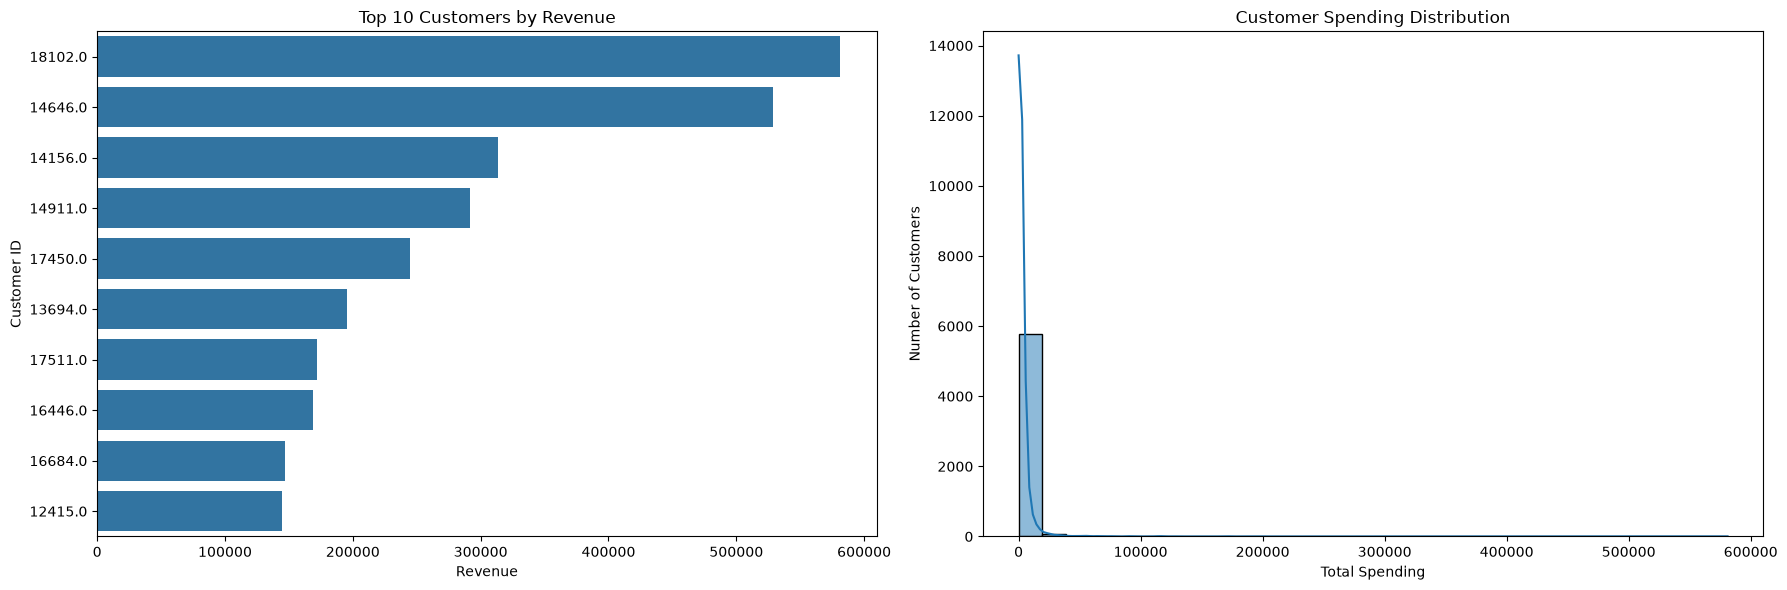

Top 10 Customers by Revenue
Customer ID
18102.0    580,987.04
14646.0    528,602.52
14156.0    313,437.62
14911.0    291,420.81
17450.0    244,784.25
13694.0    195,640.69
17511.0    172,132.87
16446.0    168,472.50
16684.0    147,142.77
12415.0    144,458.37
Name: TotalAmount, dtype: object

Customer Spending Summary
count      5,878.00
mean       2,955.90
std       14,440.85
min            2.95
25%          342.28
50%          867.74
75%        2,248.30
max      580,987.04
Name: TotalAmount, dtype: object


In [39]:
customer_sales = (df.groupby("Customer ID")["TotalAmount"].sum().sort_values(ascending=False).head(10))

customer_spending = (df.groupby("Customer ID")["TotalAmount"].sum().reset_index())

# Visualization

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x=customer_sales.values,y=customer_sales.index.astype(str),ax=axes[0])
axes[0].set_title("Top 10 Customers by Revenue")
axes[0].set_xlabel("Revenue")
axes[0].set_ylabel("Customer ID")

sns.histplot(customer_spending["TotalAmount"],bins=30,kde=True,ax=axes[1])
axes[1].set_title("Customer Spending Distribution")
axes[1].set_xlabel("Total Spending")
axes[1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

print("="*75)
print("Top 10 Customers by Revenue")
print("="*75)
print(customer_sales.map(lambda x: f"{x:,.2f}"))

print("\n"+"="*75)
print("Customer Spending Summary")
print("="*75)
print(customer_spending["TotalAmount"].describe().map(lambda x: f"{x:,.2f}"))

### Key Business Insights

- A small number of customers contribute a significant portion of total revenue.
- Most customers have relatively lower spending compared to the top customers.
- High-value customers can be targeted through loyalty programs and personalized offers.
- Understanding customer spending behavior helps improve customer retention and marketing strategies.

## Time Analysis

### Objective
The objective of this analysis is to understand customer purchasing behavior over time by analyzing monthly, weekday, hourly, and time-slot sales patterns. These insights help businesses optimize staffing, inventory management, and promotional campaigns.

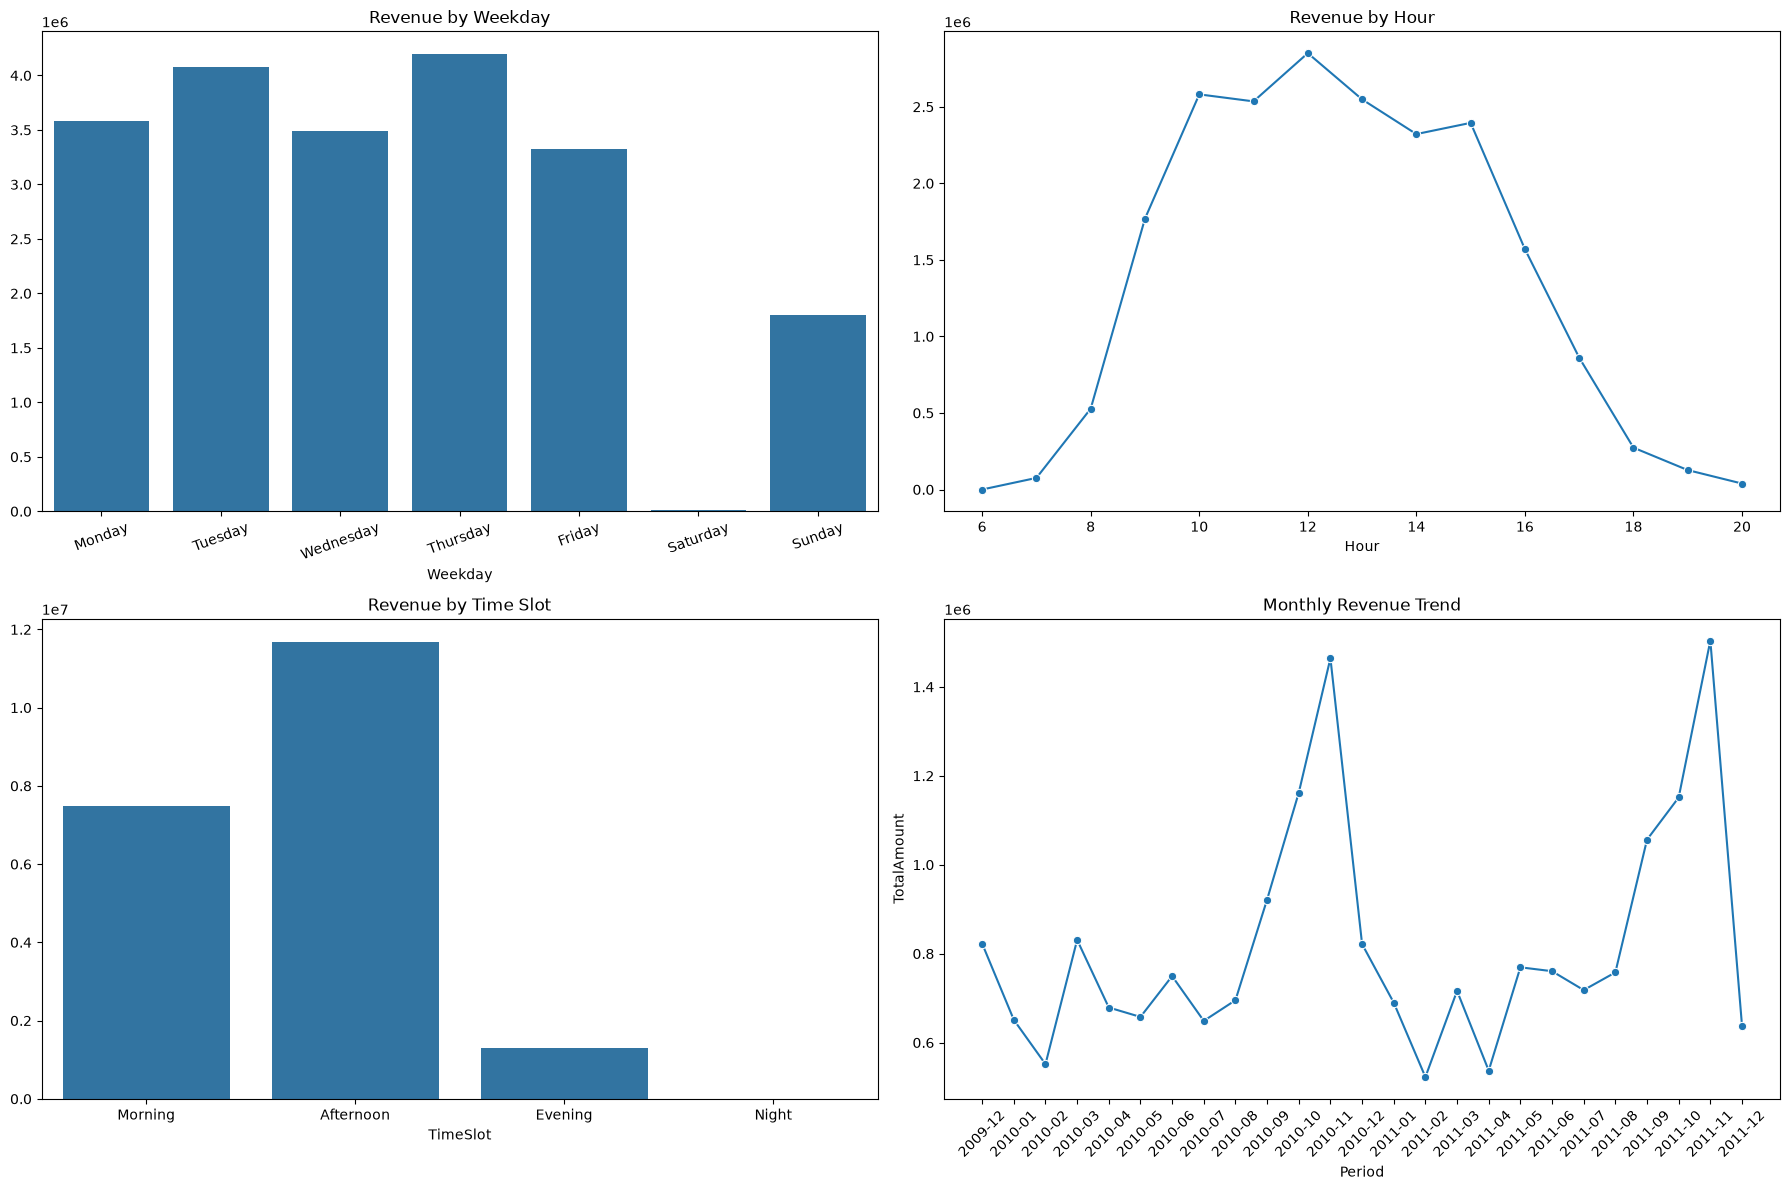

Revenue by Weekday
Weekday
Monday       3,581,594.18
Tuesday      4,078,149.96
Wednesday    3,488,444.33
Thursday     4,195,212.76
Friday       3,323,908.88
Saturday         9,803.05
Sunday       1,799,147.28
Name: TotalAmount, dtype: object

Revenue by Hour
Hour
6             4.25
7        75,765.57
8       528,185.57
9     1,769,631.03
10    2,581,131.33
11    2,535,325.46
12    2,850,377.67
13    2,548,467.54
14    2,321,684.73
15    2,394,943.79
16    1,570,143.80
17      861,460.13
18      273,405.02
19      126,830.35
20       38,904.19
Name: TotalAmount, dtype: object

Revenue by Time Slot
TimeSlot
Morning       7,490,043.22
Afternoon    11,685,617.54
Evening       1,300,599.69
Night                  nan
Name: TotalAmount, dtype: object

Monthly Revenue
     Period   TotalAmount
0   2009-12    822,483.95
1   2010-01    651,155.11
2   2010-02    551,504.73
3   2010-03    830,915.26
4   2010-04    678,875.25
5   2010-05    657,705.50
6   2010-06    749,537.31
7   2010-07    648,81

In [40]:
weekday_order = ["Monday", "Tuesday", "Wednesday","Thursday", "Friday", "Saturday", "Sunday"]

weekday_sales = (df.groupby("Weekday")["TotalAmount"].sum().reindex(weekday_order))

hourly_sales = (df.groupby("Hour")["TotalAmount"].sum())

timeslot_sales = (df.groupby("TimeSlot")["TotalAmount"].sum().reindex(["Morning", "Afternoon", "Evening", "Night"]))

monthly_sales = (df.groupby(["Year", "Month"])["TotalAmount"].sum().reset_index())
monthly_sales["Period"] = (monthly_sales["Year"].astype(str)+ "-"
    + monthly_sales["Month"].astype(str).str.zfill(2))

# Visualization

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.barplot(x=weekday_sales.index,y=weekday_sales.values,ax=axes[0,0])
axes[0,0].set_title("Revenue by Weekday")
axes[0,0].tick_params(axis="x", rotation=20)

sns.lineplot(x=hourly_sales.index,y=hourly_sales.values,marker="o",ax=axes[0,1])
axes[0,1].set_title("Revenue by Hour")

sns.barplot(x=timeslot_sales.index,y=timeslot_sales.values,ax=axes[1,0])
axes[1,0].set_title("Revenue by Time Slot")

sns.lineplot(data=monthly_sales,x="Period",y="TotalAmount",marker="o",ax=axes[1,1])
axes[1,1].set_title("Monthly Revenue Trend")
axes[1,1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("="*75)
print("Revenue by Weekday")
print("="*75)
print(weekday_sales.map(lambda x: f"{x:,.2f}"))

print("\n"+"="*75)
print("Revenue by Hour")
print("="*75)
print(hourly_sales.map(lambda x: f"{x:,.2f}"))

print("\n"+"="*75)
print("Revenue by Time Slot")
print("="*75)
print(timeslot_sales.map(lambda x: f"{x:,.2f}"))

print("\n"+"="*75)
print("Monthly Revenue")
print("="*75)
print(monthly_sales[["Period", "TotalAmount"]].assign(
      TotalAmount=monthly_sales["TotalAmount"].map(lambda x: f"{x:,.2f}")))

### Key Business Insights

- Sales are concentrated on specific weekdays, helping identify the busiest business days.
- Revenue peaks during certain hours, indicating the most active customer shopping periods.
- The majority of revenue is generated during specific time slots, which can guide staffing and promotional strategies.
- Monthly sales trends reveal seasonal demand patterns that support inventory planning and sales forecasting.
- Time-based analysis enables businesses to optimize operations and improve customer experience.

## Distribution Analysis

### Objective
The objective of this analysis is to understand the distribution of key business variables such as Quantity, Price, and Total Revenue per transaction. It also helps identify the presence of outliers and understand customer purchasing patterns.

C:\Users\HP PAVILION\anaconda3\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\HP PAVILION\anaconda3\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\HP PAVILION\anaconda3\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


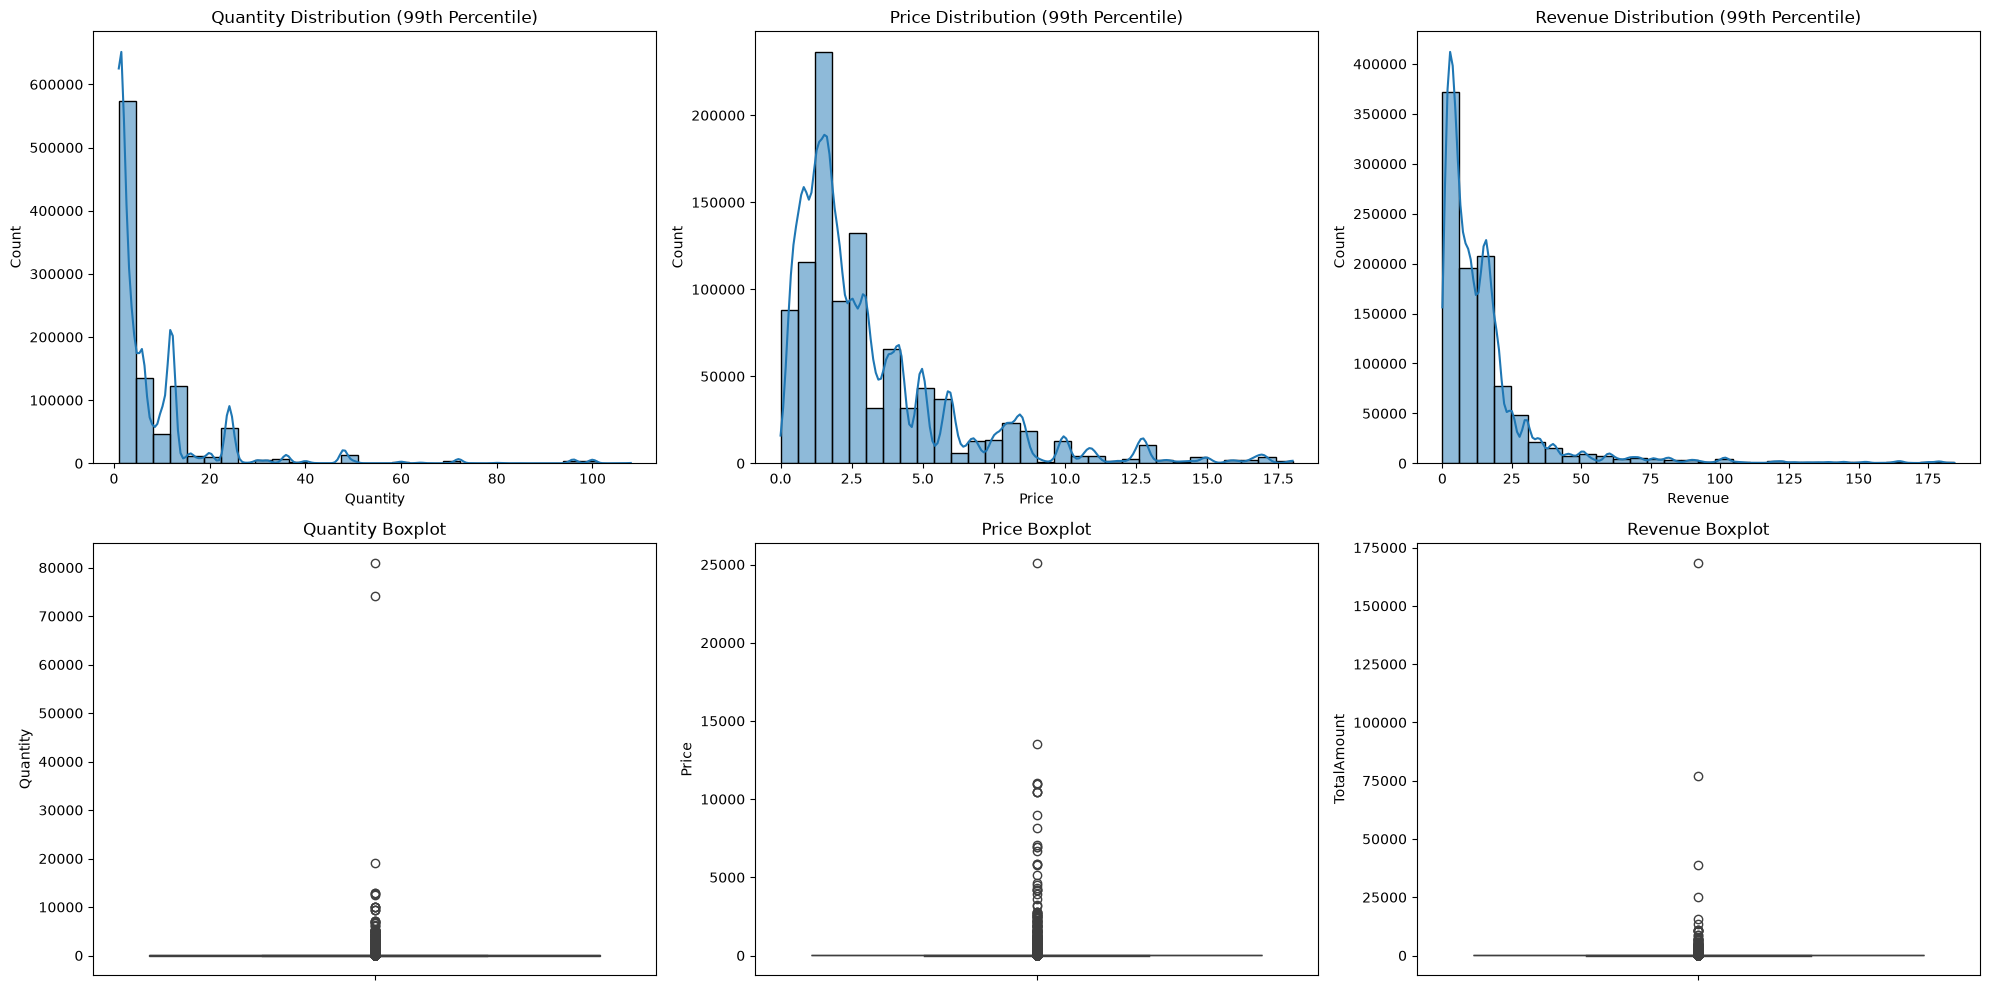

Summary Statistics
         Quantity       Price  TotalAmount
count  1007913.00  1007913.00   1007913.00
mean        11.12        4.07        20.32
std        128.47       50.43       205.72
min          1.00        0.00         0.00
25%          1.00        1.25         4.13
50%          4.00        2.10        10.08
75%         12.00        4.13        17.70
max      80995.00    25111.09    168469.60


In [41]:
# Keep only 99th percentile values for better visualization
quantity_99 = df[df["Quantity"] <= df["Quantity"].quantile(0.99)]
price_99 = df[df["Price"] <= df["Price"].quantile(0.99)]
amount_99 = df[df["TotalAmount"] <= df["TotalAmount"].quantile(0.99)]

# Visualization

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

sns.histplot(quantity_99["Quantity"],bins=30,kde=True,ax=axes[0,0])
axes[0,0].set_title("Quantity Distribution (99th Percentile)")
axes[0,0].set_xlabel("Quantity")

sns.histplot(price_99["Price"],bins=30,kde=True,ax=axes[0,1])
axes[0,1].set_title("Price Distribution (99th Percentile)")
axes[0,1].set_xlabel("Price")

sns.histplot(amount_99["TotalAmount"],bins=30,kde=True,ax=axes[0,2])
axes[0,2].set_title("Revenue Distribution (99th Percentile)")
axes[0,2].set_xlabel("Revenue")

sns.boxplot(y=df["Quantity"],ax=axes[1,0])
axes[1,0].set_title("Quantity Boxplot")

sns.boxplot(y=df["Price"],ax=axes[1,1])
axes[1,1].set_title("Price Boxplot")

sns.boxplot(y=df["TotalAmount"],ax=axes[1,2])
axes[1,2].set_title("Revenue Boxplot")

plt.tight_layout()
plt.show()

summary = (df[["Quantity", "Price", "TotalAmount"]].describe().round(2))

print("="*75)
print("Summary Statistics")
print("="*75)
print(summary)

### Key Business Insights

- Most transactions involve low quantities, while a small number of bulk purchases create extreme outliers.
- Product prices are concentrated in a lower price range, with only a few premium-priced products.
- Revenue per transaction is positively skewed, indicating that a limited number of high-value transactions contribute significantly to total revenue.
- The 99th percentile visualization provides a clearer understanding of customer purchasing behavior by reducing the visual impact of extreme outliers.
- These findings support better inventory planning, pricing strategies, and customer segmentation.

## Correlation Analysis

### Objective
The objective of this analysis is to identify the relationship between numerical features in the retail dataset. Understanding these relationships helps uncover business patterns and supports feature selection for customer segmentation and predictive analytics.

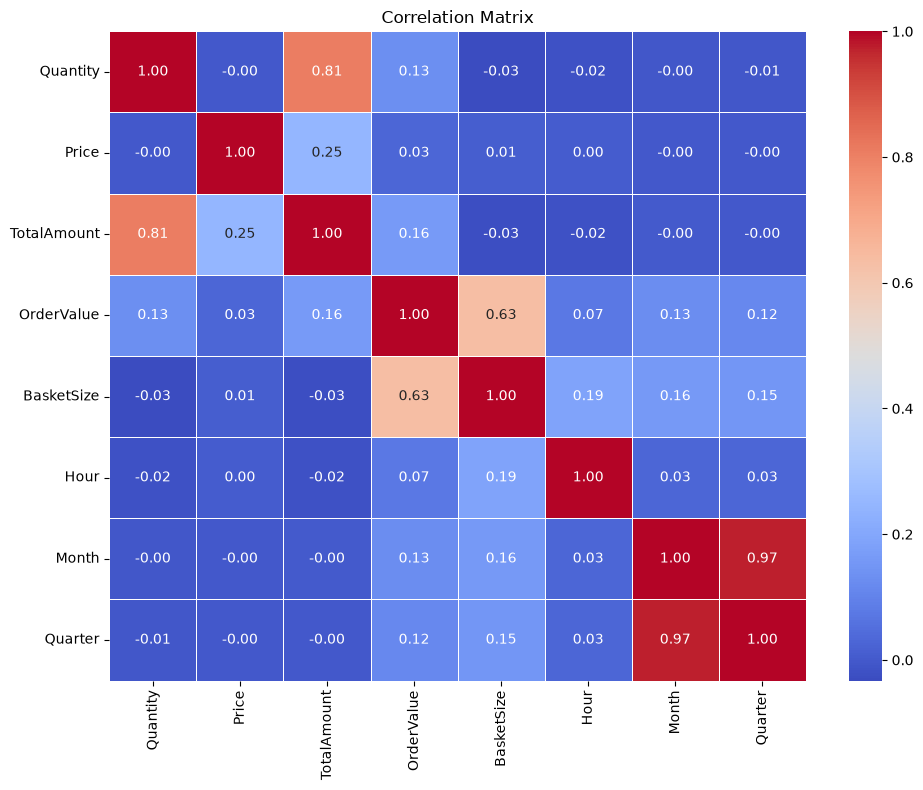

Correlation Matrix
             Quantity  Price  TotalAmount  OrderValue  BasketSize  Hour  \
Quantity         1.00  -0.00         0.81        0.13       -0.03 -0.02   
Price           -0.00   1.00         0.25        0.03        0.01  0.00   
TotalAmount      0.81   0.25         1.00        0.16       -0.03 -0.02   
OrderValue       0.13   0.03         0.16        1.00        0.63  0.07   
BasketSize      -0.03   0.01        -0.03        0.63        1.00  0.19   
Hour            -0.02   0.00        -0.02        0.07        0.19  1.00   
Month           -0.00  -0.00        -0.00        0.13        0.16  0.03   
Quarter         -0.01  -0.00        -0.00        0.12        0.15  0.03   

             Month  Quarter  
Quantity     -0.00    -0.01  
Price        -0.00    -0.00  
TotalAmount  -0.00    -0.00  
OrderValue    0.13     0.12  
BasketSize    0.16     0.15  
Hour          0.03     0.03  
Month         1.00     0.97  
Quarter       0.97     1.00  


In [42]:
numerical_features = ["Quantity","Price","TotalAmount","OrderValue",
    "BasketSize","Hour","Month","Quarter"]

correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(10,8))

sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

print("="*75)
print("Correlation Matrix")
print("="*75)

print(correlation_matrix.round(2))

### Key Business Insights

- TotalAmount shows a strong positive relationship with OrderValue, as higher transaction values directly increase order revenue.
- Quantity and TotalAmount have a positive correlation, indicating that larger purchases generally generate higher revenue.
- BasketSize has a moderate relationship with OrderValue, suggesting that larger baskets often lead to higher sales.
- Time-related features (Hour, Month, Quarter) show relatively weak correlations with revenue, indicating that purchasing behavior is influenced by multiple business factors.
- Correlation analysis helps identify important variables for customer segmentation and future machine learning models.

# Customer Segmentation using RFM Analysis

## Objective

The objective of RFM (Recency, Frequency, Monetary) Analysis is to evaluate customer purchasing behavior based on how recently they purchased, how frequently they purchase, and how much they spend. These insights help businesses identify loyal customers, high-value customers, at-risk customers, and inactive customers for targeted marketing and customer retention strategies.

In [43]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (df.groupby("Customer ID").agg({"InvoiceDate": lambda x: (reference_date - x.max()).days,
        "Invoice": "nunique","TotalAmount": "sum"}).reset_index())

rfm.columns = ["CustomerID","Recency","Frequency","Monetary"]

print("="*75)
print("RFM Table")
print("="*75)
print(rfm.head())
print("\nShape :", rfm.shape)
print("\nSummary Statistics")
print(rfm.describe().round(2))

RFM Table
   CustomerID  Recency  Frequency  Monetary
0     12346.0      326         12  77556.46
1     12347.0        2          8   4921.53
2     12348.0       75          5   2019.40
3     12349.0       19          4   4428.69
4     12350.0      310          1    334.40

Shape : (5878, 4)

Summary Statistics
       CustomerID  Recency  Frequency   Monetary
count     5878.00  5878.00    5878.00    5878.00
mean     15315.31   201.33       6.29    2955.90
std       1715.57   209.34      13.01   14440.85
min      12346.00     1.00       1.00       2.95
25%      13833.25    26.00       1.00     342.28
50%      15314.50    96.00       3.00     867.74
75%      16797.75   380.00       7.00    2248.30
max      18287.00   739.00     398.00  580987.04


## RFM Distribution Analysis

### Objective

The objective of this analysis is to understand the distribution of Recency, Frequency, and Monetary values across customers. It helps identify customer purchasing patterns, detect outliers, and evaluate data distribution before customer segmentation and clustering.

C:\Users\HP PAVILION\anaconda3\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\HP PAVILION\anaconda3\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
C:\Users\HP PAVILION\anaconda3\Lib\site-packages\seaborn\categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


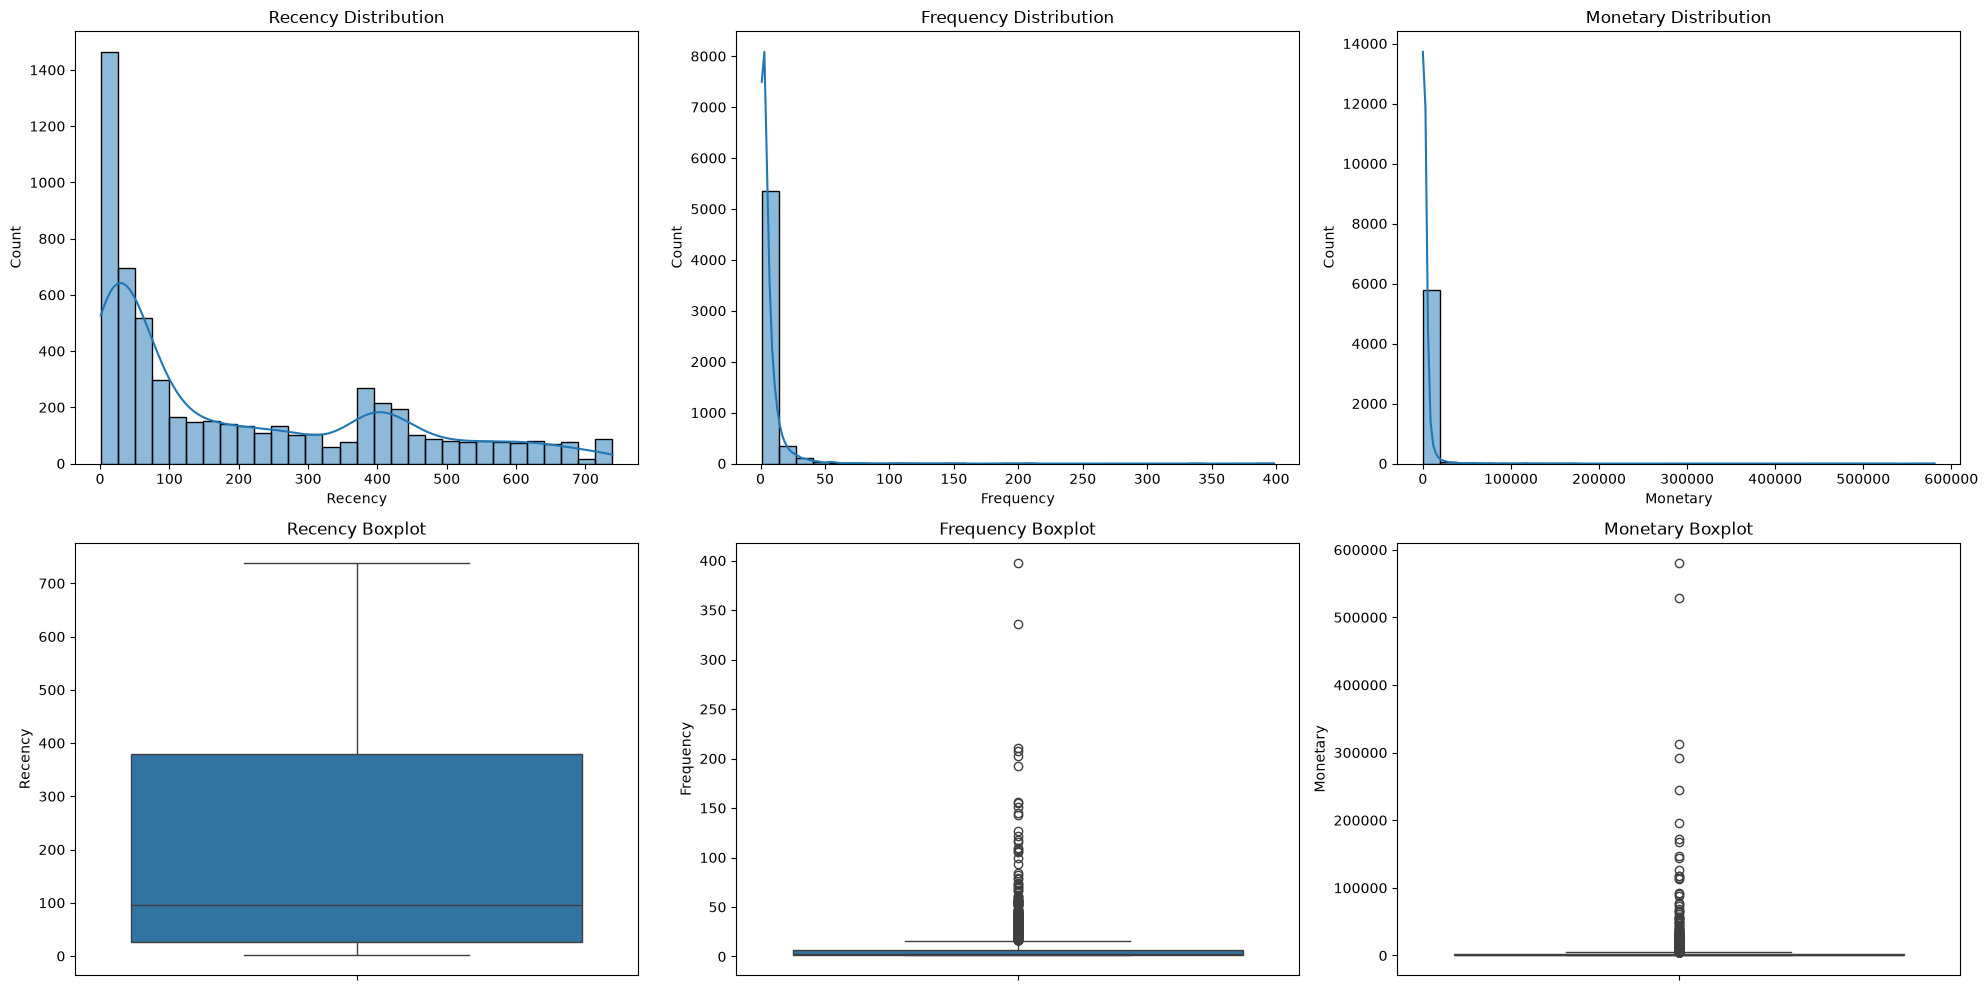

RFM Summary Statistics
       Recency  Frequency   Monetary
count  5878.00    5878.00    5878.00
mean    201.33       6.29    2955.90
std     209.34      13.01   14440.85
min       1.00       1.00       2.95
25%      26.00       1.00     342.28
50%      96.00       3.00     867.74
75%     380.00       7.00    2248.30
max     739.00     398.00  580987.04


In [44]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

sns.histplot(rfm["Recency"], bins=30, kde=True, ax=axes[0,0])
axes[0,0].set_title("Recency Distribution")

sns.boxplot(y=rfm["Recency"], ax=axes[1,0])
axes[1,0].set_title("Recency Boxplot")

sns.histplot(rfm["Frequency"], bins=30, kde=True, ax=axes[0,1])
axes[0,1].set_title("Frequency Distribution")

sns.boxplot(y=rfm["Frequency"], ax=axes[1,1])
axes[1,1].set_title("Frequency Boxplot")

sns.histplot(rfm["Monetary"], bins=30, kde=True, ax=axes[0,2])
axes[0,2].set_title("Monetary Distribution")

sns.boxplot(y=rfm["Monetary"], ax=axes[1,2])
axes[1,2].set_title("Monetary Boxplot")

plt.tight_layout()
plt.show()

print("="*75)
print("RFM Summary Statistics")
print("="*75)
print(rfm[["Recency", "Frequency", "Monetary"]].describe().round(2))

## RFM Scoring

### Objective

The objective of RFM Scoring is to assign numerical scores to each customer based on their Recency, Frequency, and Monetary values. These scores help rank customers according to their purchasing behavior and prepare the data for customer segmentation.

In [45]:
rfm["R_Score"] = pd.qcut(rfm["Recency"],q=5,labels=[5, 4, 3, 2, 1]).astype(int)

rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"),q=5,labels=[1, 2, 3, 4, 5]).astype(int)

rfm["M_Score"] = pd.qcut(rfm["Monetary"],q=5,labels=[1, 2, 3, 4, 5]).astype(int)

rfm["RFM_Score"] = (rfm["R_Score"].astype(str)+ rfm["F_Score"].astype(str)+ rfm["M_Score"].astype(str))

rfm["RFM_Total"] = (rfm["R_Score"]+ rfm["F_Score"]+ rfm["M_Score"])

print("="*75)
print("RFM Scoring")
print("="*75)
print(rfm.head())
print("\nDistribution of Total RFM Score")
print("="*75)
print(rfm["RFM_Total"].value_counts().sort_index())

RFM Scoring
   CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0     12346.0      326         12  77556.46        2        5        5   
1     12347.0        2          8   4921.53        5        4        5   
2     12348.0       75          5   2019.40        3        4        4   
3     12349.0       19          4   4428.69        5        3        5   
4     12350.0      310          1    334.40        2        1        2   

  RFM_Score  RFM_Total  
0       255         12  
1       545         14  
2       344         11  
3       535         13  
4       212          5  

Distribution of Total RFM Score
RFM_Total
3     317
4     489
5     502
6     465
7     473
8     472
9     508
10    452
11    476
12    429
13    437
14    389
15    469
Name: count, dtype: int64


### Key Business Insights

- Customers with higher RFM scores represent the most valuable and loyal customers.
- Lower RFM scores indicate inactive or low-value customers who may require re-engagement strategies.
- Combining Recency, Frequency, and Monetary values provides a comprehensive view of customer behavior.
- RFM scores serve as the foundation for customer segmentation and targeted marketing campaigns.
- The scored dataset is now ready for customer segmentation and clustering analysis.

## Customer Segmentation

### Objective

The objective of customer segmentation is to classify customers into meaningful business groups based on their RFM scores. These segments help businesses design targeted marketing campaigns, improve customer retention, and maximize customer lifetime value.

In [46]:
def customer_segment(score):

    if score >= 13:
        return "Champions"

    elif score >= 10:
        return "Loyal Customers"

    elif score >= 8:
        return "Potential Loyalists"

    elif score >= 6:
        return "Need Attention"

    else:
        return "At Risk"

rfm["Customer_Segment"] = rfm["RFM_Total"].apply(customer_segment)

segment_summary = (rfm.groupby("Customer_Segment").agg(
           Customers=("CustomerID","count"),
           Avg_Recency=("Recency","mean"),
           Avg_Frequency=("Frequency","mean"),
           Avg_Monetary=("Monetary","mean")).round(2).
           sort_values("Avg_Monetary", ascending=False))

print("="*90)
print("Customer Segment Summary")
print("="*90)
print(segment_summary)
print("\n")
print("="*90)
print("Customer Segment Distribution")
print("="*90)
print(rfm["Customer_Segment"].value_counts())

Customer Segment Summary
                     Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
Customer_Segment                                                        
Champions                 1295        25.82          17.96       9678.17
Loyal Customers           1357        95.75           5.57       2263.05
Potential Loyalists        980       180.83           3.01        947.70
Need Attention             938       258.88           1.82        554.62
At Risk                   1308       458.73           1.14        245.91


Customer Segment Distribution
Customer_Segment
Loyal Customers        1357
At Risk                1308
Champions              1295
Potential Loyalists     980
Need Attention          938
Name: count, dtype: int64


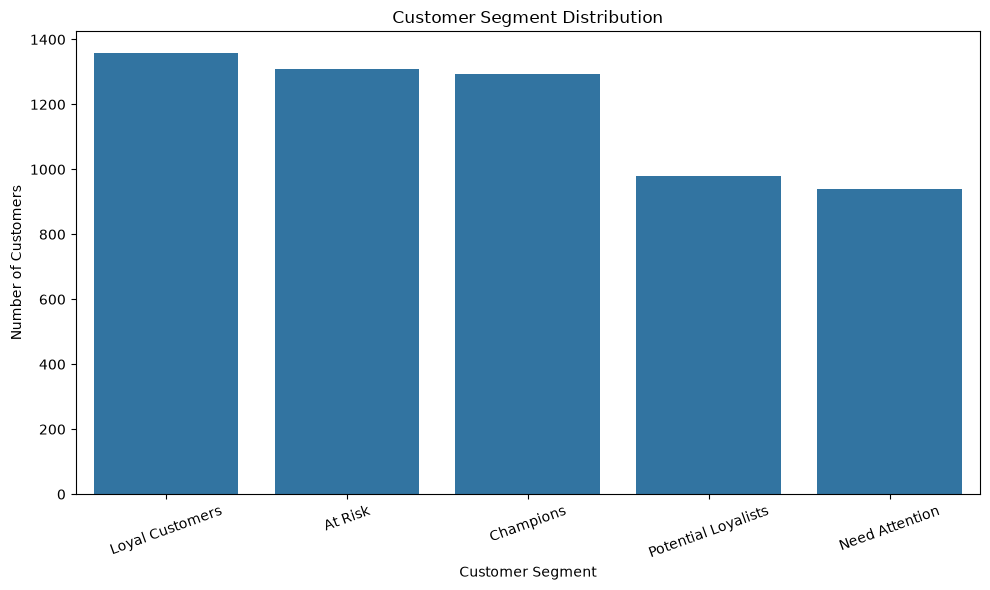

In [47]:
plt.figure(figsize=(10,6))

sns.countplot(data=rfm,x="Customer_Segment",
    order=rfm["Customer_Segment"].value_counts().index)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Key Business Insights

- Champions are the most valuable customers with high purchase frequency and high spending.
- Loyal Customers contribute consistently to business revenue and should be retained through loyalty programs.
- Potential Loyalists can become high-value customers with personalized offers and engagement.
- Customers in the Need Attention segment require targeted campaigns to increase their purchase activity.
- At Risk customers have low engagement and should be reactivated through retention strategies before they become inactive.

# K-Means Clustering

## Data Scaling
### Objective

The objective of data scaling is to standardize the RFM features so that Recency, Frequency, and Monetary contribute equally during clustering. Since K-Means is a distance-based algorithm, feature scaling is essential for accurate customer segmentation.

In [48]:
rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

rfm_scaled = pd.DataFrame(rfm_scaled,columns=rfm_features.columns)

print("="*75)
print("Scaled RFM Data")
print("="*75)
print(rfm_scaled.head())
print("\nShape :", rfm_scaled.shape)
print("\nSummary Statistics")
print("="*75)
print(rfm_scaled.describe().round(2))

Scaled RFM Data
    Recency  Frequency  Monetary
0  0.595584   0.438998  5.166378
1 -0.952279   0.131502  0.136127
2 -0.603532  -0.099120 -0.064857
3 -0.871064  -0.175994  0.101996
4  0.519146  -0.406616 -0.181549

Shape : (5878, 3)

Summary Statistics
       Recency  Frequency  Monetary
count  5878.00    5878.00   5878.00
mean     -0.00      -0.00      0.00
std       1.00       1.00      1.00
min      -0.96      -0.41     -0.20
25%      -0.84      -0.41     -0.18
50%      -0.50      -0.25     -0.14
75%       0.85       0.05     -0.05
max       2.57      30.11     40.03


### Key Business Insights

- Recency, Frequency, and Monetary are now on the same scale.
- Feature scaling prevents Monetary values from dominating the clustering process.
- Standardized features improve the accuracy and stability of K-Means clustering.
- The scaled dataset is now ready for identifying the optimal number of customer clusters.

## Elbow Method

### Objective

The objective of the Elbow Method is to determine the optimal number of clusters (K) for K-Means clustering. It evaluates the Within-Cluster Sum of Squares (WCSS) for different values of K and identifies the point where adding more clusters provides only marginal improvement.

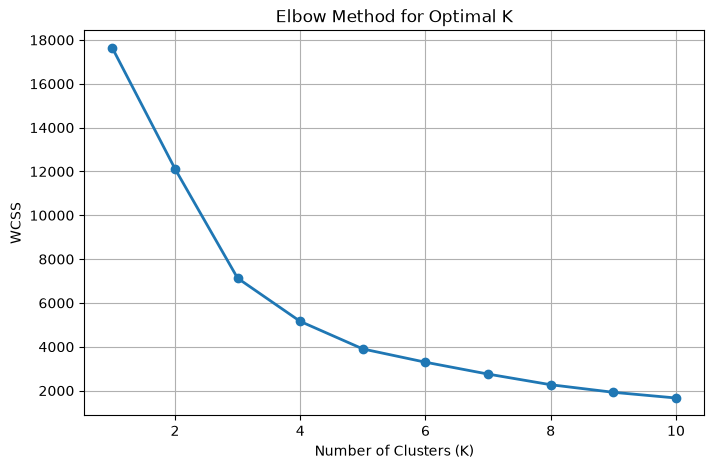

Elbow Method Results
    K      WCSS
0   1  17634.00
1   2  12123.74
2   3   7130.82
3   4   5158.49
4   5   3901.21
5   6   3295.38
6   7   2753.62
7   8   2267.80
8   9   1922.45
9  10   1662.79


In [49]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):

    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o',linewidth=2)
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

elbow_df = pd.DataFrame({"K": range(1,11),"WCSS": np.round(wcss,2)})

print("="*60)
print("Elbow Method Results")
print("="*60)
print(elbow_df)

### Key Business Insights

- WCSS decreases as the number of clusters increases because data points are grouped more closely.
- The optimal number of clusters is identified at the "elbow point," where the reduction in WCSS starts to slow down.
- Choosing the correct K helps balance model simplicity and clustering accuracy.
- The selected K will be used to build the final K-Means customer segmentation model.

## K-Means Clustering

### Objective

The objective of K-Means clustering is to group customers with similar purchasing behavior using the scaled RFM features. This helps businesses identify distinct customer groups for personalized marketing and strategic decision-making.

In [50]:
kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

cluster_summary = (rfm.groupby("Cluster").agg(
           Customers=("CustomerID", "count"),
           Avg_Recency=("Recency", "mean"),
           Avg_Frequency=("Frequency", "mean"),
           Avg_Monetary=("Monetary", "mean")).round(2))

print("="*80)
print("K-Means Cluster Summary")
print("="*80)
print(cluster_summary)
print("\n")
print("="*80)
print("Cluster Distribution")
print("="*80)
print(rfm["Cluster"].value_counts().sort_index())

K-Means Cluster Summary
         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
Cluster                                                     
0             3838        67.05           7.27       2921.08
1             1998       463.03           2.21        748.54
2                4         3.50         212.50     428612.00
3               38        24.26         100.13      77728.27


Cluster Distribution
Cluster
0    3838
1    1998
2       4
3      38
Name: count, dtype: int64


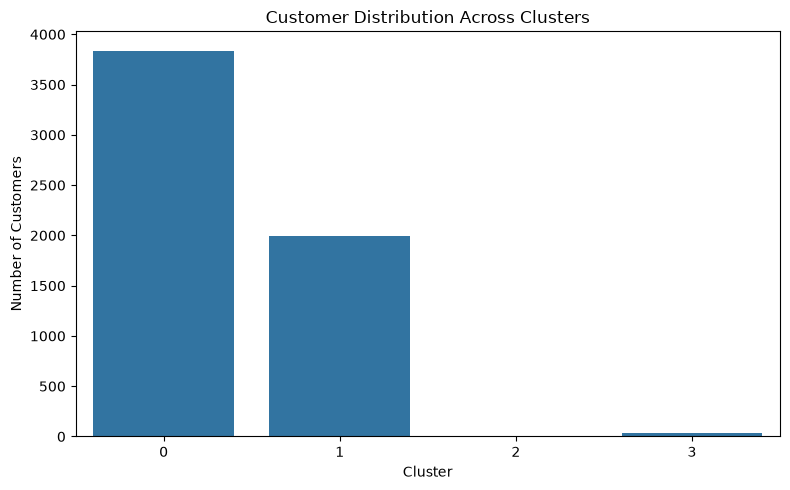

In [51]:
plt.figure(figsize=(8,5))

sns.countplot(data=rfm,x="Cluster")

plt.title("Customer Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### Key Business Insights

- Customers have been grouped into four distinct clusters based on their purchasing behavior.
- Each cluster represents customers with different levels of recency, purchase frequency, and spending.
- These customer groups enable targeted marketing, personalized promotions, and better customer relationship management.
- Cluster analysis provides a data-driven approach to customer segmentation beyond traditional RFM scoring.

In [52]:
cluster_names = {0: "Regular Customers",
                 1: "At Risk Customers",
                 2: "VIP Customers",
                 3: "High Value Customers"}

rfm["Customer_Type"] = rfm["Cluster"].map(cluster_names)

print("="*80)
print("Customer Type Distribution")
print("="*80)
print(rfm["Customer_Type"].value_counts())

Customer Type Distribution
Customer_Type
Regular Customers       3838
At Risk Customers       1998
High Value Customers      38
VIP Customers              4
Name: count, dtype: int64


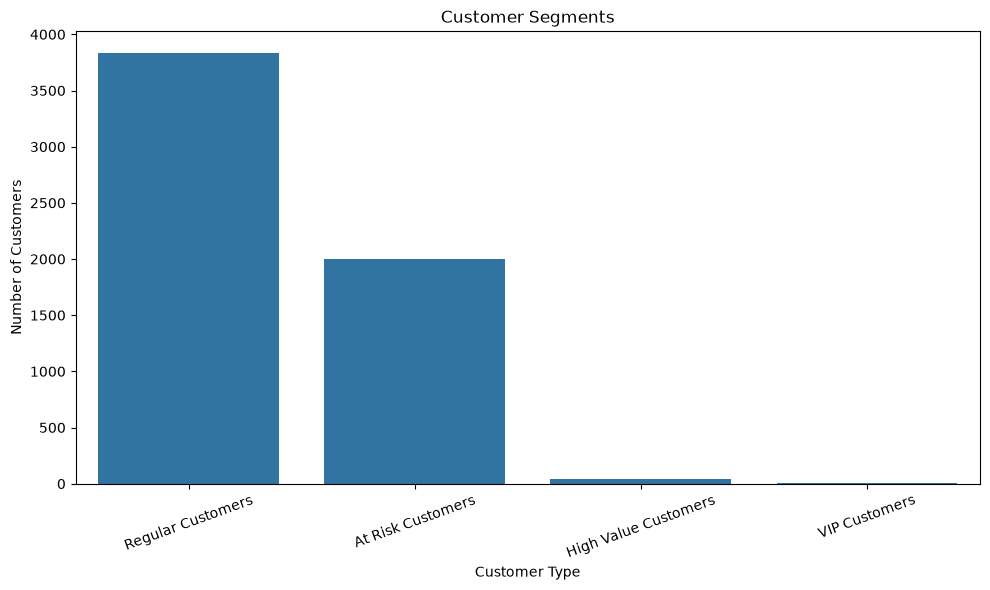

In [53]:
plt.figure(figsize=(10,6))
sns.countplot(data=rfm,x="Customer_Type",
              order=rfm["Customer_Type"].value_counts().index)

plt.title("Customer Segments")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Key Business Insights

- VIP Customers represent a very small but extremely valuable customer group with the highest spending and purchase frequency.
- High Value Customers contribute significantly to business revenue and should be retained through exclusive offers and loyalty programs.
- Regular Customers form the largest customer base and represent stable business revenue.
- At Risk Customers have low purchase frequency and high recency, indicating that they may stop purchasing unless re-engagement strategies are implemented.
- Customer segmentation enables businesses to deliver personalized marketing campaigns and improve customer lifetime value.

## Silhouette Score Evaluation

### Objective

The objective of the Silhouette Score is to evaluate the quality of the K-Means clustering model. It measures how well each customer fits within its assigned cluster while remaining distinct from other clusters. A higher Silhouette Score indicates better cluster separation and more meaningful customer segmentation.

In [54]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(rfm_scaled, rfm["Cluster"])

print("="*75)
print("Silhouette Score")
print("="*75)

print(f"Silhouette Score : {sil_score:.4f}")

if sil_score >= 0.70:
    print("\nExcellent Cluster Separation")
elif sil_score >= 0.50:
    print("\nGood Cluster Separation")
elif sil_score >= 0.25:
    print("\nAverage Cluster Separation")
else:
    print("\nPoor Cluster Separation")

Silhouette Score
Silhouette Score : 0.5913

Good Cluster Separation


### Key Business Insights

- The K-Means model achieved a Silhouette Score of **0.5913**, indicating good cluster separation.
- The selected value of **K = 4** provides meaningful and well-defined customer groups.
- Customers within each cluster exhibit similar purchasing behavior, while different clusters remain well separated.
- The clustering model is suitable for customer segmentation and business decision-making.
- The validated clusters can now be visualized using Principal Component Analysis (PCA).

## Principal Component Analysis (PCA)

### Objective

The objective of Principal Component Analysis (PCA) is to reduce the three-dimensional RFM data into two principal components while preserving most of the information. This visualization helps understand how customers are grouped into different clusters and validates the effectiveness of K-Means clustering.

Explained Variance Ratio
PC1 : 0.5763
PC2 : 0.3046

Total Variance Explained : 0.8809


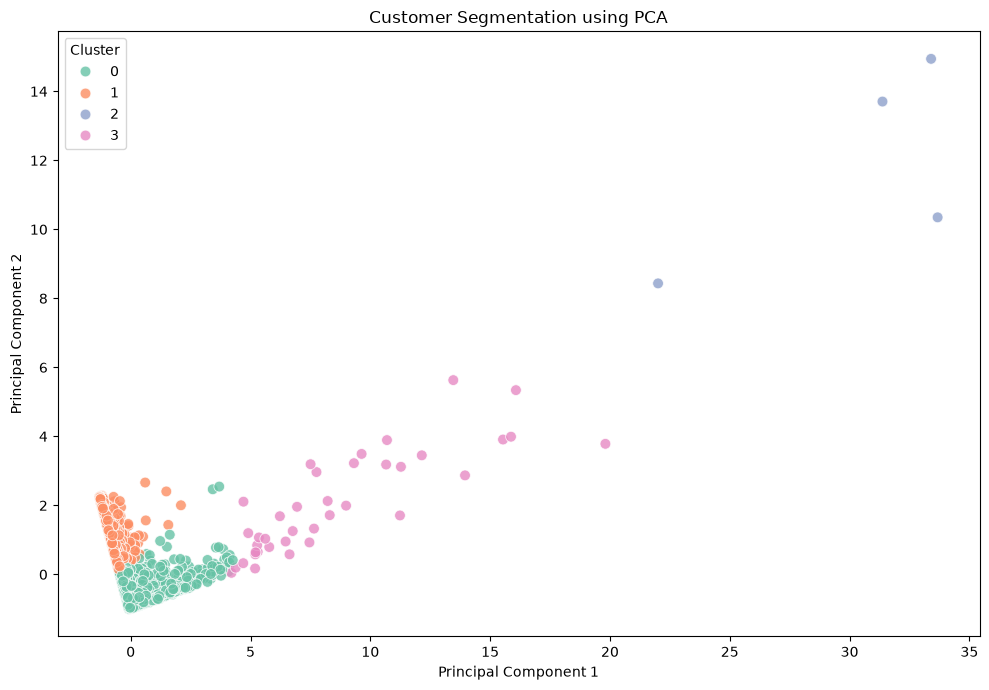

In [55]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

pca_components = pca.fit_transform(rfm_scaled)

pca_df = pd.DataFrame(pca_components,columns=["PC1", "PC2"])
pca_df["Cluster"] = rfm["Cluster"]

explained_variance = pca.explained_variance_ratio_

print("="*75)
print("Explained Variance Ratio")
print("="*75)
print(f"PC1 : {explained_variance[0]:.4f}")
print(f"PC2 : {explained_variance[1]:.4f}")
print(f"\nTotal Variance Explained : {explained_variance.sum():.4f}")

plt.figure(figsize=(10,7))

sns.scatterplot(data=pca_df,x="PC1",y="PC2",hue="Cluster",palette="Set2",s=60,alpha=0.8)

plt.title("Customer Segmentation using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

### Key Business Insights

- PCA reduced the three RFM features into two principal components while retaining **88.09%** of the original information.
- The visualization shows clear separation among customer clusters, confirming the effectiveness of the K-Means clustering model.
- VIP Customers appear as a distinct cluster, indicating exceptional purchasing behavior compared to other customer groups.
- Regular and At Risk customers form larger groups with different purchasing patterns, enabling targeted business strategies.
- PCA provides a clear and interpretable visualization of customer segmentation for business decision-making and stakeholder presentations.

# DBSCAN Clustering

## Objective

The objective of DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is to identify customer groups based on data density without specifying the number of clusters in advance. It also detects outliers (noise points), making it suitable for discovering irregular customer behavior in retail data.

In [56]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8,min_samples=10)

rfm["DBSCAN_Cluster"] = dbscan.fit_predict(rfm_scaled)

dbscan_summary = (rfm.groupby("DBSCAN_Cluster").agg
                 (Customers=("CustomerID", "count"),
                  Avg_Recency=("Recency", "mean"),
                  Avg_Frequency=("Frequency", "mean"),
                  Avg_Monetary=("Monetary", "mean")).round(2))

print("="*80)
print("DBSCAN Cluster Summary")
print("="*80)
print(dbscan_summary)
print("\n")
print("="*80)
print("Cluster Distribution")
print("="*80)
print(rfm["DBSCAN_Cluster"].value_counts().sort_index())

DBSCAN Cluster Summary
                Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
DBSCAN_Cluster                                                     
-1                     55        84.58          89.38      95099.42
 0                   5823       202.43           5.50       2085.58


Cluster Distribution
DBSCAN_Cluster
-1      55
 0    5823
Name: count, dtype: int64


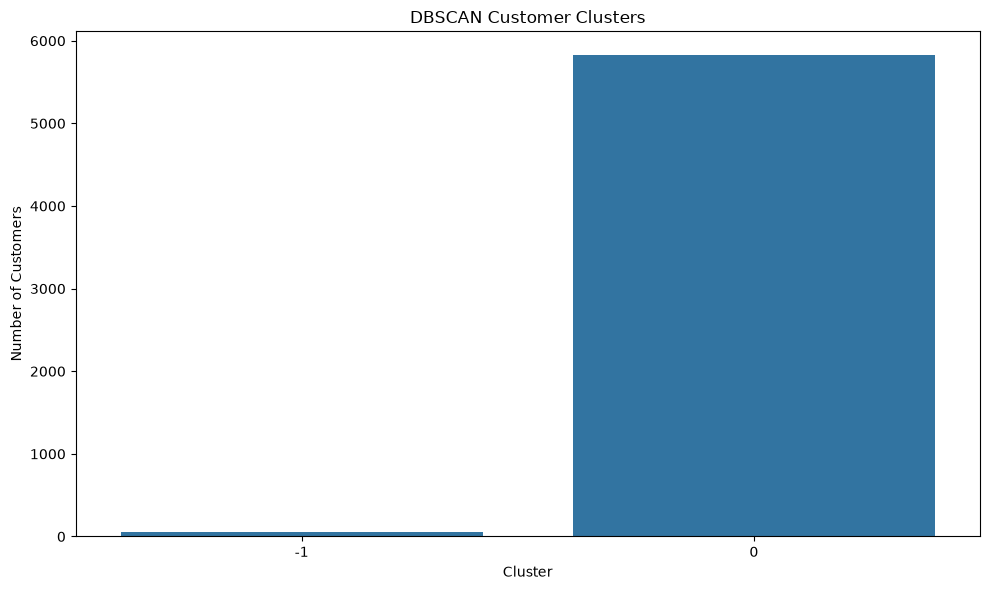

In [57]:
plt.figure(figsize=(10,6))

sns.countplot(data=rfm,x="DBSCAN_Cluster",order=sorted(rfm["DBSCAN_Cluster"].unique()))

plt.title("DBSCAN Customer Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Key Business Insights

- DBSCAN identified one major customer cluster and a small number of outlier customers.
- Around 55 customers were classified as noise, indicating unusual purchasing behavior.
- Unlike K-Means, DBSCAN did not separate the customer base into multiple meaningful business segments for this dataset.
- This comparison suggests that K-Means is more suitable for customer segmentation on the given retail dataset.

# Hierarchical Clustering

## Objective

The objective of Hierarchical Clustering is to group customers based on their similarity using a tree-like hierarchy called a dendrogram. Unlike K-Means, it does not require predefined cluster assignments initially and helps visualize how customer groups are formed.

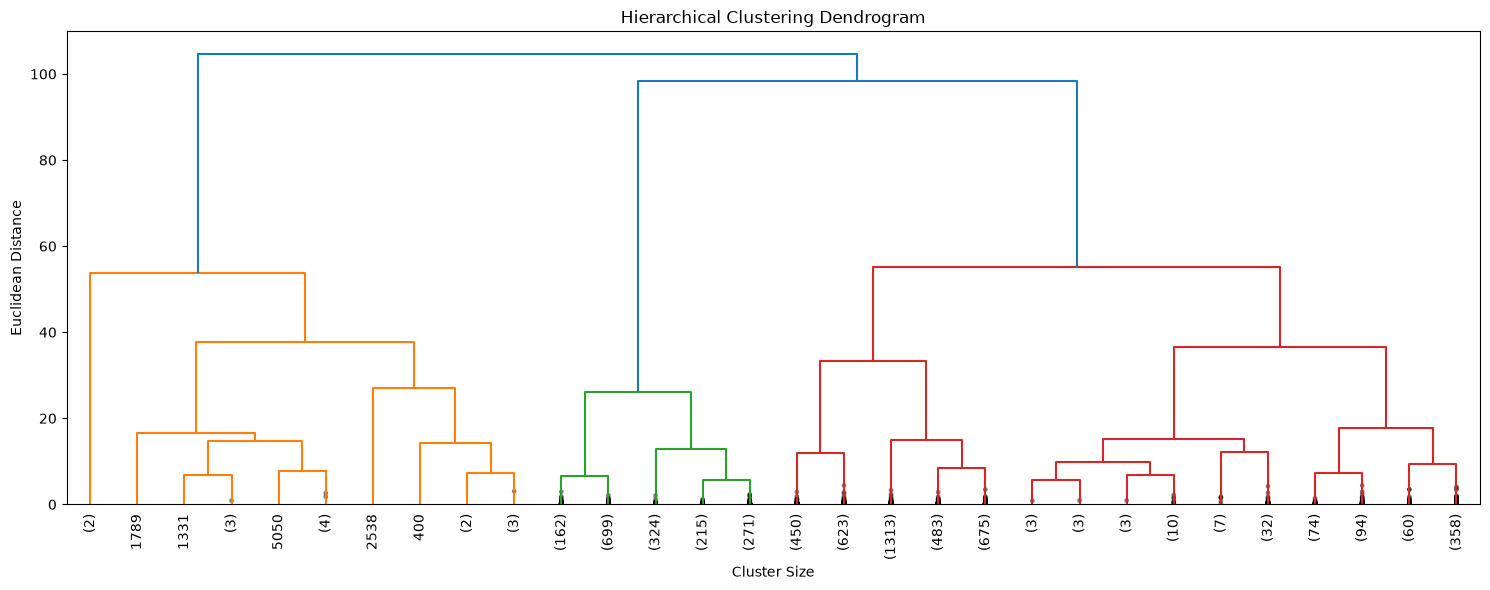

In [58]:
from scipy.cluster.hierarchy import linkage, dendrogram

linked = linkage(rfm_scaled,method="ward")

plt.figure(figsize=(15,6))

dendrogram(linked,truncate_mode="lastp",p=30,leaf_rotation=90,leaf_font_size=10,show_contracted=True)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster Size")
plt.ylabel("Euclidean Distance")
plt.tight_layout()
plt.show()

### Key Business Insights

- The dendrogram visualizes how customer groups are merged based on similarity.
- Ward linkage minimizes within-cluster variance, producing compact customer groups.
- The largest vertical gap in the dendrogram indicates the most appropriate number of clusters.
- Hierarchical clustering provides an intuitive understanding of customer relationships before assigning final clusters.

## Hierarchical Clustering Model

### Objective

The objective of Hierarchical Clustering is to assign customers into meaningful groups based on the dendrogram structure. This analysis provides an alternative customer segmentation approach and allows comparison with K-Means and DBSCAN clustering.

In [59]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=4,linkage="ward")

rfm["HC_Cluster"] = hc.fit_predict(rfm_scaled)

hc_summary = (rfm.groupby("HC_Cluster").agg
             (Customers=("CustomerID","count"),
              Avg_Recency=("Recency","mean"),
              Avg_Frequency=("Frequency","mean"),
              Avg_Monetary=("Monetary","mean")).round(2))

print("="*80)
print("Hierarchical Cluster Summary")
print("="*80)
print(hc_summary)
print("\n")
print("="*80)
print("Cluster Distribution")
print("="*80)
print(rfm["HC_Cluster"].value_counts().sort_index())

Hierarchical Cluster Summary
            Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
HC_Cluster                                                     
0                  19        25.37         149.79     188430.24
1                 644        37.13          23.72      11468.70
2                1671       495.89           2.15        727.22
3                3544        93.23           4.30       1465.46


Cluster Distribution
HC_Cluster
0      19
1     644
2    1671
3    3544
Name: count, dtype: int64


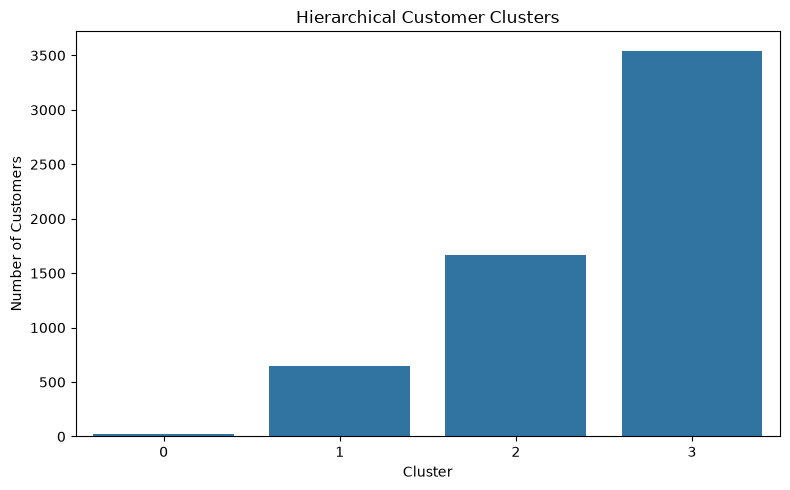

In [60]:
plt.figure(figsize=(8,5))

sns.countplot(data=rfm,x="HC_Cluster")

plt.title("Hierarchical Customer Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### Key Business Insights

- Hierarchical Clustering divided customers into four meaningful groups based on purchasing behavior.
- The dendrogram supported the selection of four clusters, which is consistent with the K-Means analysis.
- Hierarchical clustering provides an interpretable view of how customer groups are formed through successive merging.
- Comparing Hierarchical Clustering with K-Means and DBSCAN helps identify the most suitable segmentation technique for the retail dataset.

In [61]:
hc_cluster_names = {0: "VIP Customers",
                    1: "High Value Customers",
                    2: "At Risk Customers",
                    3: "Regular Customers"}

rfm["HC_Customer_Type"] = rfm["HC_Cluster"].map(hc_cluster_names)

print("="*80)
print("Hierarchical Customer Segments")
print("="*80)

print(rfm["HC_Customer_Type"].value_counts())

Hierarchical Customer Segments
HC_Customer_Type
Regular Customers       3544
At Risk Customers       1671
High Value Customers     644
VIP Customers             19
Name: count, dtype: int64


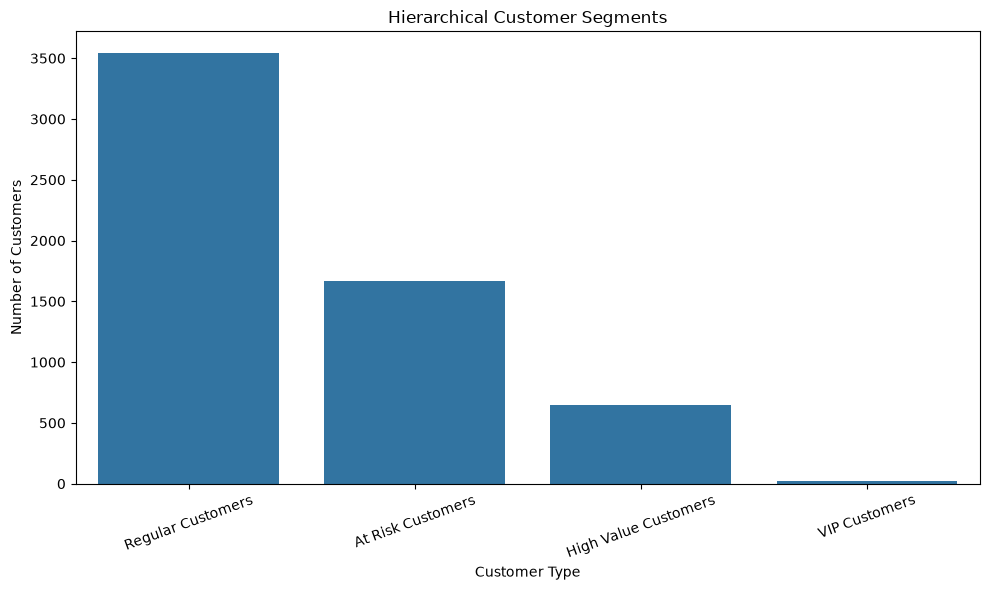

In [62]:
plt.figure(figsize=(10,6))

sns.countplot(data=rfm,x="HC_Customer_Type",
              order=rfm["HC_Customer_Type"].value_counts().index)

plt.title("Hierarchical Customer Segments")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Key Business Insights

- Hierarchical Clustering identified four distinct customer groups with different purchasing behaviors.
- VIP Customers represent a small but highly profitable customer segment with exceptional spending and purchase frequency.
- High Value Customers contribute significantly to business revenue and should be retained through personalized offers.
- At Risk Customers have not purchased recently and require targeted retention campaigns.
- Regular Customers form the largest customer segment and provide consistent business revenue.

# Market Basket Analysis

## Objective

The objective of Market Basket Analysis is to identify products that are frequently purchased together using association rule mining techniques. These insights help businesses improve product bundling, cross-selling, shelf placement, and promotional strategies.

In [65]:
basket_df = df.dropna(subset=["Description", "Invoice"])

top_products = (basket_df["Description"].value_counts().head(300).index)

basket_df = basket_df[basket_df["Description"].isin(top_products)]
top_invoices = basket_df["Invoice"].unique()[:10000]

basket_df = basket_df[basket_df["Invoice"].isin(top_invoices)]

basket = pd.crosstab(basket_df["Invoice"],basket_df["Description"])

basket = (basket > 0).astype("int8")

print("="*70)
print("Basket Shape")
print("="*70)
print(basket.shape)
print("\n")
print(basket.head())

Basket Shape
(10000, 245)


Description  12 PENCILS SMALL TUBE SKULL  3 HEARTS HANGING DECORATION RUSTIC  \
Invoice                                                                        
489434                                 0                                   0   
489436                                 0                                   0   
489437                                 0                                   0   
489438                                 0                                   0   
489439                                 0                                   0   

Description  3 STRIPEY MICE FELTCRAFT  4 TRADITIONAL SPINNING TOPS  \
Invoice                                                              
489434                              0                            0   
489436                              0                            0   
489437                              0                            0   
489438                              0                        

### Key Business Insights

- Each row represents a unique customer transaction (Invoice).
- Each column represents a product purchased in the retail store.
- Binary encoding (1 = Purchased, 0 = Not Purchased) prepares the data for association rule mining.
- The transaction matrix serves as the foundation for Apriori and FP-Growth algorithms.

## Apriori Algorithm

### Objective

The objective of the Apriori algorithm is to discover frequent itemsets from customer transactions. These frequent itemsets help identify products that are commonly purchased together and form the basis for generating association rules.

In [67]:
basket = basket.astype(bool)

from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(basket,min_support=0.03,use_colnames=True,low_memory=True,max_len=2)

frequent_itemsets["Item_Count"] = frequent_itemsets["itemsets"].apply(len)

frequent_itemsets = frequent_itemsets.sort_values(by="support",ascending=False)

print("="*75)
print("Frequent Itemsets")
print("="*75)
print(frequent_itemsets.head(20))
print("\nTotal Frequent Itemsets :", len(frequent_itemsets))

Frequent Itemsets
     support                              itemsets  Item_Count
112   0.1992  (WHITE HANGING HEART T-LIGHT HOLDER)           1
66    0.1104    (PACK OF 72 RETRO SPOT CAKE CASES)           1
102   0.1004      (STRAWBERRY CERAMIC TRINKET BOX)           1
86    0.0912            (REGENCY CAKESTAND 3 TIER)           1
53    0.0905                (LUNCH BAG RED SPOTTY)           1
1     0.0802         (60 TEATIME FAIRY CAKE CASES)           1
32    0.0791            (HOME BUILDING BLOCK WORD)           1
94    0.0760    (SET/20 RED SPOTTY PAPER NAPKINS )           1
4     0.0745       (ASSORTED COLOUR BIRD ORNAMENT)           1
6     0.0731       (BAKING SET 9 PIECE RETROSPOT )           1
70    0.0724                       (PARTY BUNTING)           1
96    0.0697    (SET/5 RED SPOTTY LID GLASS BOWLS)           1
48    0.0688            (LOVE BUILDING BLOCK WORD)           1
64    0.0684  (PACK OF 60 PINK PAISLEY CAKE CASES)           1
46    0.0683              (JUMBO STOR

### Key Business Insights

- The Apriori algorithm identifies products that are frequently purchased together across customer transactions.
- Support measures how often an itemset appears in the dataset, helping businesses identify popular product combinations.
- Frequent itemsets provide the foundation for generating association rules such as cross-selling and product bundling.
- Memory optimization techniques were applied to efficiently analyze the retail dataset on limited hardware resources.

## Association Rules

### Objective

The objective of Association Rule Mining is to discover meaningful relationships between products that are frequently purchased together. These rules help businesses identify cross-selling opportunities, product bundling strategies, and recommendation systems using support, confidence, and lift metrics.

In [68]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets,metric="confidence",min_threshold=0.40)

rules = rules[["antecedents","consequents","support","confidence","lift"]]

rules = rules.sort_values(by="lift",ascending=False)

print("="*80)
print("Association Rules")
print("="*80)
print(rules.head(20))
print("\nTotal Rules :", len(rules))

Association Rules
                             antecedents  \
12   (WOODEN PICTURE FRAME WHITE FINISH)   
11         (WOODEN FRAME ANTIQUE WHITE )   
3       (SWEETHEART CERAMIC TRINKET BOX)   
4       (STRAWBERRY CERAMIC TRINKET BOX)   
6             (LOVE BUILDING BLOCK WORD)   
7             (HOME BUILDING BLOCK WORD)   
8          (60 TEATIME FAIRY CAKE CASES)   
9   (PACK OF 60 PINK PAISLEY CAKE CASES)   
10             (LUNCH BAG  BLACK SKULL.)   
2   (PACK OF 60 PINK PAISLEY CAKE CASES)   
16            (LUNCH BAG PINK RETROSPOT)   
13      (72 SWEETHEART FAIRY CAKE CASES)   
0          (60 TEATIME FAIRY CAKE CASES)   
1     (PACK OF 72 RETRO SPOT CAKE CASES)   
5     (RED HANGING HEART T-LIGHT HOLDER)   
14         (WOODEN FRAME ANTIQUE WHITE )   
15            (LOVE BUILDING BLOCK WORD)   

                             consequents  support  confidence       lift  
12         (WOODEN FRAME ANTIQUE WHITE )   0.0329    0.671429  10.051326  
11   (WOODEN PICTURE FRAME WHITE FINISH

### Key Business Insights

- A total of **17 strong association rules** were generated from the transaction data.
- The strongest rule achieved a **Lift greater than 10**, indicating a very strong relationship between the associated products.
- High-confidence rules suggest products that customers are likely to purchase together, making them suitable for cross-selling and product bundling.
- Association rules provide valuable insights for recommendation systems, shelf arrangement, and targeted promotions.
- These findings can help retailers increase sales by recommending complementary products during customer purchases.

## FP-Growth Algorithm

### Objective

The objective of the FP-Growth algorithm is to identify frequent itemsets efficiently without generating candidate itemsets. Compared to Apriori, FP-Growth is faster and more memory-efficient for large retail datasets, making it suitable for real-world market basket analysis.

In [70]:
from mlxtend.frequent_patterns import fpgrowth

fp_itemsets = fpgrowth(basket,min_support=0.03,use_colnames=True)

fp_itemsets["Item_Count"] = fp_itemsets["itemsets"].apply(len)

fp_itemsets = fp_itemsets.sort_values(by="support",ascending=False)

print("="*75)
print("FP-Growth Frequent Itemsets")
print("="*75)
print(fp_itemsets.head(20))
print("\nTotal Frequent Itemsets :", len(fp_itemsets))

FP-Growth Frequent Itemsets
     support                              itemsets  Item_Count
14    0.1992  (WHITE HANGING HEART T-LIGHT HOLDER)           1
35    0.1104    (PACK OF 72 RETRO SPOT CAKE CASES)           1
0     0.1004      (STRAWBERRY CERAMIC TRINKET BOX)           1
114   0.0912            (REGENCY CAKESTAND 3 TIER)           1
21    0.0905                (LUNCH BAG RED SPOTTY)           1
33    0.0802         (60 TEATIME FAIRY CAKE CASES)           1
1     0.0791            (HOME BUILDING BLOCK WORD)           1
69    0.0760    (SET/20 RED SPOTTY PAPER NAPKINS )           1
2     0.0745       (ASSORTED COLOUR BIRD ORNAMENT)           1
9     0.0731       (BAKING SET 9 PIECE RETROSPOT )           1
75    0.0724                       (PARTY BUNTING)           1
56    0.0697    (SET/5 RED SPOTTY LID GLASS BOWLS)           1
3     0.0688            (LOVE BUILDING BLOCK WORD)           1
34    0.0684  (PACK OF 60 PINK PAISLEY CAKE CASES)           1
44    0.0683              (

### Key Business Insights

- FP-Growth successfully identified **135 frequent itemsets**, matching the Apriori algorithm on the optimized transaction dataset.
- The algorithm efficiently discovered popular products without generating candidate itemsets.
- The most frequently purchased products can be used for product recommendations, inventory planning, and promotional campaigns.
- FP-Growth demonstrated better computational efficiency while producing the same frequent itemsets as Apriori.

# Final Business Report

## Objective

The objective of this report is to summarize the key findings from retail sales analysis, customer segmentation, clustering techniques, and market basket analysis. The report provides actionable business insights and strategic recommendations to improve customer retention, increase sales, and support data-driven decision-making.

In [71]:
# Final Project Summary

print("="*90)
print("SMART RETAIL ANALYTICS & CUSTOMER SEGMENTATION PLATFORM")
print("="*90)

print("\nProject Summary")
print("-"*90)

print("Dataset               : Online Retail II")
print(f"Total Transactions    : {df['Invoice'].nunique():,}")
print(f"Total Customers       : {df['Customer ID'].nunique():,}")
print(f"Total Products        : {df['StockCode'].nunique():,}")
print(f"Total Revenue         : {df['TotalAmount'].sum():,.2f}")

print("\nMachine Learning Models")
print("-"*90)

print("1. RFM Analysis")
print("2. K-Means Clustering")
print("3. DBSCAN Clustering")
print("4. Hierarchical Clustering")
print("5. PCA")
print("6. Apriori Algorithm")
print("7. FP-Growth Algorithm")

print("\nProject Status : COMPLETED")

SMART RETAIL ANALYTICS & CUSTOMER SEGMENTATION PLATFORM

Project Summary
------------------------------------------------------------------------------------------
Dataset               : Online Retail II
Total Transactions    : 40,077
Total Customers       : 5,878
Total Products        : 4,917
Total Revenue         : 20,476,260.45

Machine Learning Models
------------------------------------------------------------------------------------------
1. RFM Analysis
2. K-Means Clustering
3. DBSCAN Clustering
4. Hierarchical Clustering
5. PCA
6. Apriori Algorithm
7. FP-Growth Algorithm

Project Status : COMPLETED


## Executive Summary

- Successfully analyzed the Online Retail II dataset using end-to-end data analytics and machine learning techniques.
- Built customer segments using RFM Analysis and multiple clustering algorithms.
- Compared K-Means, DBSCAN, and Hierarchical Clustering for customer segmentation.
- Performed Market Basket Analysis using Apriori and FP-Growth algorithms.
- Generated actionable business insights to improve customer retention, cross-selling, and product recommendations.


## Business Recommendations

### Customer Retention
- Reward VIP and High Value Customers through loyalty programs and exclusive offers.
- Launch re-engagement campaigns for At Risk Customers using personalized discounts.

### Product Recommendations
- Recommend products that are frequently purchased together using association rules.
- Create product bundles based on frequent itemsets to increase average order value.

### Marketing Strategy
- Personalize promotions for different customer segments.
- Target Regular Customers with upselling campaigns.

### Inventory Management
- Maintain sufficient stock of frequently purchased products.
- Optimize shelf placement for products with high lift values.

### Business Intelligence
- Monitor customer behavior regularly using RFM analysis.
- Update customer segments periodically to support data-driven decision-making.


## Future Scope

- Build an interactive dashboard using Power BI or Tableau.
- Deploy the solution as a web application using Streamlit.
- Implement a real-time recommendation system.
- Integrate Customer Lifetime Value (CLV) prediction.
- Apply deep learning techniques for advanced recommendation systems.


# Project Conclusion

This project successfully demonstrated an end-to-end retail analytics workflow using the Online Retail II dataset. The analysis included data cleaning, feature engineering, exploratory data analysis, customer segmentation through RFM analysis and clustering algorithms, and market basket analysis using Apriori and FP-Growth.

Among the clustering techniques, K-Means produced the most meaningful customer segments, while FP-Growth proved to be a more efficient approach for frequent pattern mining on large datasets. The project generated valuable business insights that can support customer retention, product recommendations, cross-selling, inventory optimization, and strategic business decision-making.

<div style="background-color:#111827;
            color:white;
            padding:30px;
            border-radius:15px;
            text-align:center;
            box-shadow:0px 0px 15px gray;">

<h1>🛒 Smart Retail Analytics & Customer Segmentation Platform</h1>

<h2>End-to-End Machine Learning Project</h2>

</div>

<br>

<div style="background-color:#F0FFF4;
            border-left:8px solid #22C55E;
            padding:20px;
            border-radius:10px;">

<h2>🎯 Project Objective</h2>

<p>

Build a complete End-to-End Retail Analytics and Customer Segmentation solution using the Online Retail II Dataset.

The project includes:

</p>

<ul>

<li>✅ Data Collection</li>

<li>✅ Data Cleaning</li>

<li>✅ Feature Engineering</li>

<li>✅ Business KPI Analysis</li>

<li>✅ Exploratory Data Analysis (EDA)</li>

<li>✅ Customer Segmentation using RFM Analysis</li>

<li>✅ K-Means Clustering</li>

<li>✅ DBSCAN Clustering</li>

<li>✅ Hierarchical Clustering</li>

<li>✅ Principal Component Analysis (PCA)</li>

<li>✅ Market Basket Analysis</li>

<li>✅ Apriori Algorithm</li>

<li>✅ Association Rule Mining</li>

<li>✅ FP-Growth Algorithm</li>

<li>✅ Business Recommendations</li>

</ul>

</div>

<br>

# 📂 Project Workflow

---

## ✅ Data Collection

- Imported Online Retail II Dataset
- Imported Required Libraries

---

## ✅ Data Understanding

- Dataset Shape
- Dataset Information
- Data Types
- Missing Values
- Duplicate Records
- Statistical Summary

---

## ✅ Data Cleaning

- Removed Missing Values
- Removed Duplicate Records
- Removed Cancelled Transactions
- Removed Invalid Quantity
- Removed Invalid Unit Price

---

## ✅ Feature Engineering

- Total Amount
- Order Value
- Basket Size
- Invoice Year
- Invoice Month
- Invoice Day
- Invoice Hour
- Quarter
- Weekend
- Time Slot

---

## ✅ Business KPI Analysis

- Total Revenue
- Total Orders
- Total Customers
- Total Products
- Average Basket Size
- Average Revenue per Customer

---

## ✅ Exploratory Data Analysis (EDA)

- Monthly Revenue Analysis
- Country-wise Sales
- Top Selling Products
- Customer Purchase Analysis
- Revenue Distribution
- Correlation Heatmap

---

## ✅ Customer Segmentation

- RFM Analysis
- RFM Scoring
- Customer Segments

---

<div style="background:#EEF6FF;
border-left:6px solid #3B82F6;
padding:20px;
border-radius:10px;">

<h2>🤖 Machine Learning Models</h2>

✔ RFM Analysis <br><br>

✔ K-Means Clustering <br><br>

✔ DBSCAN Clustering <br><br>

✔ Hierarchical Clustering <br><br>

✔ Principal Component Analysis (PCA) <br><br>

✔ Apriori Algorithm <br><br>

✔ FP-Growth Algorithm

</div>

---

<div style="padding:10px;">

<h2>📊 Model Evaluation</h2>

The following techniques were used:

<ul>

<li>Silhouette Score</li>

<li>Cluster Visualization</li>

<li>PCA Visualization</li>

<li>Association Rules</li>

<li>Support</li>

<li>Confidence</li>

<li>Lift</li>

</ul>

</div>

---

<div style="padding:10px;">

<h2>🏆 Business Analysis</h2>

The project successfully identified:

✔ High Value Customers <br><br>

✔ VIP Customers <br><br>

✔ Regular Customers <br><br>

✔ At-Risk Customers <br><br>

✔ Frequently Purchased Product Combinations <br><br>

✔ Customer Buying Patterns

</div>

---

<div style="background:#FFF8E6;
border-left:6px solid #F59E0B;
padding:20px;
border-radius:10px;">

<h2>🚀 Skills Demonstrated</h2>

Python <br><br>

NumPy <br><br>

Pandas <br><br>

Matplotlib <br><br>

Seaborn <br><br>

Scikit-Learn <br><br>

MLxtend <br><br>

Data Cleaning <br><br>

Feature Engineering <br><br>

Exploratory Data Analysis (EDA) <br><br>

Business Analytics <br><br>

RFM Analysis <br><br>

Customer Segmentation <br><br>

K-Means Clustering <br><br>

DBSCAN Clustering <br><br>

Hierarchical Clustering <br><br>

Principal Component Analysis (PCA) <br><br>

Market Basket Analysis <br><br>

Apriori Algorithm <br><br>

FP-Growth Algorithm

</div>

---

<div style="background:#EFFAFF;
border-left:6px solid #38BDF8;
padding:20px;
border-radius:10px;">

<h2>🎉 Final Conclusion</h2>

<p>

This project demonstrates a complete End-to-End Retail Analytics and Customer Segmentation workflow using Data Analytics and Machine Learning techniques.

The Online Retail II dataset was cleaned, transformed, and analyzed to generate valuable business insights. Customer segmentation was performed using RFM Analysis, K-Means, DBSCAN, and Hierarchical Clustering. Market Basket Analysis was carried out using Apriori and FP-Growth algorithms to discover product associations.

The insights generated from this project can help businesses improve customer retention, optimize marketing strategies, increase cross-selling opportunities, and support data-driven decision-making.

</p>

</div>

---

<center>

<h1 style="color:#EAB308;">
⭐ Thank You ⭐
</h1>

<h3>
End-to-End Retail Analytics & Customer Segmentation Platform
</h3>

</center>